<a href="https://colab.research.google.com/github/igarashi50/ExoPlayer/blob/dev-v1/estimatedMu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [124]:
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt

# データ構造
@dataclass
class MovingPoint:
    distance: float
    time: float

# --- 2次フィット関数 ---
def quadratic_fit(points):
    """
    MovingPointのリストを受け取り、
    2次フィットの係数 (a, b, c) と numpy.poly1dオブジェクトを返す
    """
    tBegin = points[0].time
    times = np.array([p.time - tBegin for p in points])
    distances = np.array([p.distance for p in points])

    coeffs = np.polyfit(times, distances, 2)
    a, b, c = coeffs
    fit_func = np.poly1d(coeffs)
    return a, b, c, fit_func


# --- 描画関数 ---
def plot_quadratic_fit(points):
    # --- フィット ---
    a, b, c, f = quadratic_fit(points)
    mu = -2 * a / 9.81
    tBegin = points[0].time
    tEnd = points[-1].time
    v = 2 * a * (tEnd-tBegin) + b
    s = v * v / (2 * -a)
    print(f"2次関数: distance = {a:.6f} * time^2 + {b:.6f} * time + {c:.6f}")
    print(f"摩擦係数: mu={mu:.6f} 最終速度(AtNearCup): v={v: .6f} 到達距離(FromNearCup): s={s:.2f}")

    # --- 配列抽出 ---
    times = np.array([p.time - tBegin for p in points])
    distances = np.array([p.distance for p in points])

    # --- 各ポイントの速度（差分から計算）---
    speeds = [np.nan]
    for i in range(1, len(points)):
        dt = times[i] - times[i - 1]
        dd = distances[i] - distances[i - 1]
        v = dd / dt if dt != 0 else np.nan
        speeds.append(v)
        print(f"i={i} time={times[i]: 0.6f} distance={distances[i]:0.2f} dt={dt:0.6f} dd={dd:0.6f} v={v:0.6f}")
    speeds = np.array(speeds)

    # --- フィット曲線 ---
    fit_times = np.linspace(times.min(), times.max(), 200)
    fit_distances = f(fit_times)

    # --- フィット速度（理論値: 2a*t + b）---
    fit_speeds = 2 * a * times + b  # 各MovingPoint.timeでの速度

    # --- プロット ---
    fig, ax1 = plt.subplots(figsize=(6, 4))

    # 距離（左軸）
    ax1.set_xlabel('Time [s]')
    ax1.set_ylabel('Distance', color='blue')
    ax1.scatter(times, distances, color='blue', label='Distance (data)', s=30)
    ax1.plot(fit_times, fit_distances, color='blue', linestyle='--', label='Distance (fit)')
    ax1.tick_params(axis='y', labelcolor='blue')

    # 速度（右軸）
    ax2 = ax1.twinx()
    ax2.set_ylabel('Speed', color='red')

    # 差分速度（実測）
    ax2.plot(times, speeds, color='red', marker='o', label='Speed (Δd/Δt)')
    # フィット速度（理論）
    ax2.plot(times, fit_speeds, color='red', linestyle='--', linewidth=2, label='Speed (fit: 2a*t+b)')

    ax2.tick_params(axis='y', labelcolor='red')

    # タイトルと凡例
    fig.suptitle('Quadratic Fit: Distance & Speed vs Time')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    fig.tight_layout()
    plt.grid(True)
    plt.show()



2次関数: distance = 0.571306 * time^2 + 0.793462 * time + -0.219997
摩擦係数: mu=-0.116474 最終速度(AtNearCup): v= 0.526853 到達距離(FromNearCup): s=-0.24
i=1 time= 0.033333 distance=-0.20 dt=0.033333 dd=0.010493 v=0.314779
i=2 time= 0.066667 distance=-0.16 dt=0.033333 dd=0.041261 v=1.237837
i=3 time= 0.100000 distance=-0.13 dt=0.033333 dd=0.029404 v=0.882128
i=4 time= 0.133333 distance=-0.10 dt=0.033333 dd=0.037294 v=1.118806
i=5 time= 0.166667 distance=-0.07 dt=0.033333 dd=0.021728 v=0.651836
i=6 time= 0.200000 distance=-0.05 dt=0.033333 dd=0.028530 v=0.855915
i=7 time= 0.233333 distance=-0.00 dt=0.033333 dd=0.045760 v=1.372801


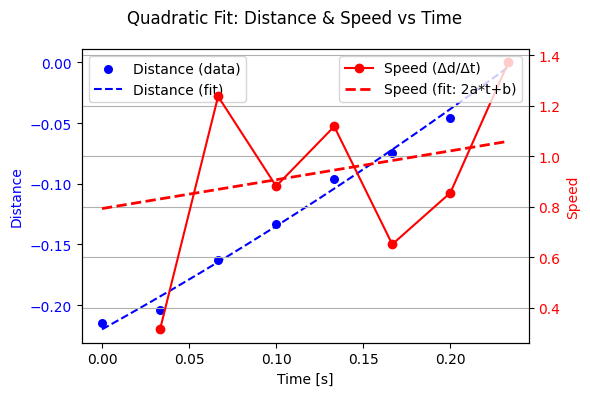

In [79]:
data_points_20251017_121144 = [
MovingPoint(time=0.0, distance=-0.214470032760488),
MovingPoint(time=0.03333333333333144, distance=-0.20397739701948456),
MovingPoint(time=0.06666666666666288, distance=-0.1627161740380837),
MovingPoint(time=0.10000000000000142, distance=-0.13331189841207103),
MovingPoint(time=0.13333333333333286, distance=-0.09601837993501322),
MovingPoint(time=0.1666666666666643, distance=-0.07429051809921675),
MovingPoint(time=0.19999999999999574, distance=-0.045760024141414155),
MovingPoint(time=0.23333333333333428, distance=-0.0),
]
plot_quadratic_fit(data_points_20251017_121144)

2次関数: distance = 0.571306 * time^2 + 0.793462 * time + -0.219997
摩擦係数: mu=-0.116474 最終速度(AtNearCup): v= 0.526853 到達距離(FromNearCup): s=-0.24
i=1 time= 0.033333 distance=-0.20 dt=0.033333 dd=0.010493 v=0.314779
i=2 time= 0.066667 distance=-0.16 dt=0.033333 dd=0.041261 v=1.237837
i=3 time= 0.100000 distance=-0.13 dt=0.033333 dd=0.029404 v=0.882128
i=4 time= 0.133333 distance=-0.10 dt=0.033333 dd=0.037294 v=1.118806
i=5 time= 0.166667 distance=-0.07 dt=0.033333 dd=0.021728 v=0.651836
i=6 time= 0.200000 distance=-0.05 dt=0.033333 dd=0.028530 v=0.855915
i=7 time= 0.233333 distance=-0.00 dt=0.033333 dd=0.045760 v=1.372801


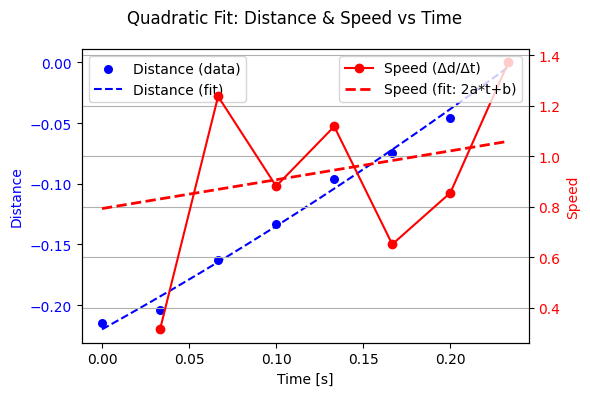

In [80]:
data_points_20251017_122355 = [
MovingPoint(time=0.0, distance=-0.214470032760488),
MovingPoint(time=0.03333333333333144, distance=-0.20397739701948456),
MovingPoint(time=0.06666666666666288, distance=-0.1627161740380837),
MovingPoint(time=0.10000000000000142, distance=-0.13331189841207103),
MovingPoint(time=0.13333333333333286, distance=-0.09601837993501322),
MovingPoint(time=0.1666666666666643, distance=-0.07429051809921675),
MovingPoint(time=0.19999999999999574, distance=-0.045760024141414155),
MovingPoint(time=0.23333333333333428, distance=-0.0),
]

#-------- FitResult --------
#a=0.5713061660517913, b=0.793462220781047, c=-0.2199973764817383
#endPosition=(-0.017981710257315778, 0.4913532603702768, 0.4916821822888024)
#endBallSpeed=(1.0600717649385507)
#ballDirection=-89.51297577706443 deg
#mu=-0.11647424384338252
#estimatedMu=0.035
#----------------------------
###
plot_quadratic_fit(data_points_20251017_122355)

【Python版】Zスコアによる外れ値除去＋切片あり回帰

2次関数: distance = 0.571306 * time^2 + 0.793462 * time + -0.219997
摩擦係数: mu=-0.116474 最終速度(AtNearCup): v= 0.526853 到達距離(FromNearCup): s=-0.24
i=1 time= 0.033333 distance=-0.20 dt=0.033333 dd=0.010493 v=0.314779
i=2 time= 0.066667 distance=-0.16 dt=0.033333 dd=0.041261 v=1.237837
i=3 time= 0.100000 distance=-0.13 dt=0.033333 dd=0.029404 v=0.882128
i=4 time= 0.133333 distance=-0.10 dt=0.033333 dd=0.037294 v=1.118806
i=5 time= 0.166667 distance=-0.07 dt=0.033333 dd=0.021728 v=0.651836
i=6 time= 0.200000 distance=-0.05 dt=0.033333 dd=0.028530 v=0.855915
i=7 time= 0.233333 distance=-0.00 dt=0.033333 dd=0.045760 v=1.372801


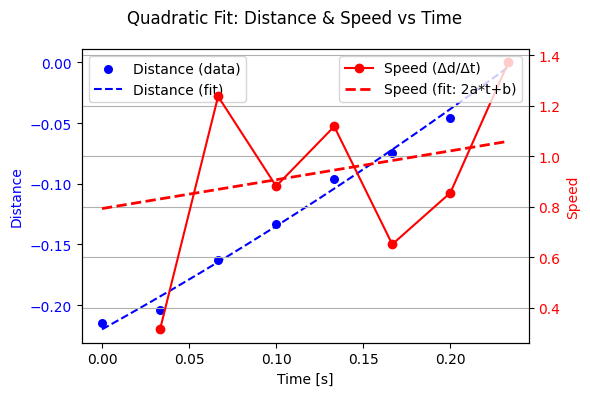

In [81]:
data_points_20251017_122905 = [
MovingPoint(time=0.0, distance=-0.214470032760488),
MovingPoint(time=0.03333333333333144, distance=-0.20397739701948456),
MovingPoint(time=0.06666666666666288, distance=-0.1627161740380837),
MovingPoint(time=0.10000000000000142, distance=-0.13331189841207103),
MovingPoint(time=0.13333333333333286, distance=-0.09601837993501322),
MovingPoint(time=0.1666666666666643, distance=-0.07429051809921675),
MovingPoint(time=0.19999999999999574, distance=-0.045760024141414155),
MovingPoint(time=0.23333333333333428, distance=-0.0),
]
#-------- FitResult --------
#a=0.5713061660517913, b=0.793462220781047, c=-0.2199973764817383
#endPosition=(-0.017981710257315778, 0.4913532603702768, 0.4916821822888024)
#endBallSpeed=(1.0600717649385507)
#ballDirection=-89.51297577706443 deg
#mu=-0.11647424384338252
#estimatedMu=0.035
#----------------------------
plot_quadratic_fit(data_points_20251017_122905)

2次関数: distance = -0.338401 * time^2 + 0.982588 * time + -0.223162
摩擦係数: mu=0.068991 最終速度(AtNearCup): v= 1.320989 到達距離(FromNearCup): s=2.58
i=1 time=-0.233333 distance=-0.48 dt=0.033333 dd=0.038032 v=1.140948
i=2 time=-0.200000 distance=-0.43 dt=0.033333 dd=0.044741 v=1.342239
i=3 time=-0.166667 distance=-0.39 dt=0.033333 dd=0.035988 v=1.079651
i=4 time=-0.133333 distance=-0.35 dt=0.033333 dd=0.041116 v=1.233482
i=5 time=-0.100000 distance=-0.32 dt=0.033333 dd=0.030124 v=0.903733
i=6 time=-0.066667 distance=-0.29 dt=0.033333 dd=0.037729 v=1.131881
i=7 time=-0.033333 distance=-0.25 dt=0.033333 dd=0.031469 v=0.944062
i=8 time= 0.000000 distance=-0.21 dt=0.033333 dd=0.039805 v=1.194149
i=9 time= 0.033333 distance=-0.20 dt=0.033333 dd=0.010493 v=0.314779
i=10 time= 0.066667 distance=-0.16 dt=0.033333 dd=0.041261 v=1.237837
i=11 time= 0.100000 distance=-0.13 dt=0.033333 dd=0.029404 v=0.882128
i=12 time= 0.133333 distance=-0.10 dt=0.033333 dd=0.037294 v=1.118806
i=13 time= 0.166667 distance=-

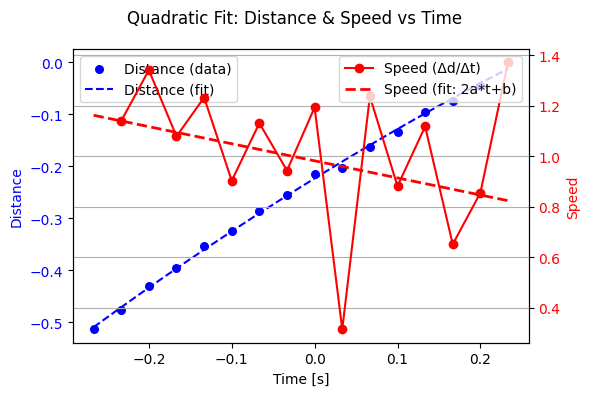

In [82]:
data_points_20251017_142726 = [
MovingPoint(time=-0.2666666666666657, distance=-0.5134748282803577),
MovingPoint(time=-0.23333333333333428, distance=-0.47544321429315817),
MovingPoint(time=-0.20000000000000284, distance=-0.4307019224359515),
MovingPoint(time=-0.1666666666666714, distance=-0.3947135478086449),
MovingPoint(time=-0.13333333333333286, distance=-0.35359749732255846),
MovingPoint(time=-0.10000000000000142, distance=-0.32347307418509447),
MovingPoint(time=-0.06666666666666998, distance=-0.2857437182732934),
MovingPoint(time=-0.033333333333338544, distance=-0.2542749985551053),
MovingPoint(time=0.0, distance=-0.214470032760488),
MovingPoint(time=0.03333333333333144, distance=-0.20397739701948456),
MovingPoint(time=0.06666666666666288, distance=-0.1627161740380837),
MovingPoint(time=0.10000000000000142, distance=-0.13331189841207103),
MovingPoint(time=0.13333333333333286, distance=-0.09601837993501322),
MovingPoint(time=0.1666666666666643, distance=-0.07429051809921675),
MovingPoint(time=0.19999999999999574, distance=-0.045760024141414155),
MovingPoint(time=0.23333333333333428, distance=-0.0)
]
plot_quadratic_fit(data_points_20251017_142726 )

2次関数: distance = -0.338401 * time^2 + 1.163068 * time + -0.509250
摩擦係数: mu=0.068991 最終速度(AtNearCup): v= 1.501469 到達距離(FromNearCup): s=3.33
i=1 time= 0.033333 distance=-0.48 dt=0.033333 dd=0.038032 v=1.140948
i=2 time= 0.066667 distance=-0.43 dt=0.033333 dd=0.044741 v=1.342239
i=3 time= 0.100000 distance=-0.39 dt=0.033333 dd=0.035988 v=1.079651
i=4 time= 0.133333 distance=-0.35 dt=0.033333 dd=0.041116 v=1.233482
i=5 time= 0.166667 distance=-0.32 dt=0.033333 dd=0.030124 v=0.903733
i=6 time= 0.200000 distance=-0.29 dt=0.033333 dd=0.037729 v=1.131881
i=7 time= 0.233333 distance=-0.25 dt=0.033333 dd=0.031469 v=0.944062
i=8 time= 0.266667 distance=-0.21 dt=0.033333 dd=0.039805 v=1.194149
i=9 time= 0.300000 distance=-0.20 dt=0.033333 dd=0.010493 v=0.314779
i=10 time= 0.333333 distance=-0.16 dt=0.033333 dd=0.041261 v=1.237837
i=11 time= 0.366667 distance=-0.13 dt=0.033333 dd=0.029404 v=0.882128
i=12 time= 0.400000 distance=-0.10 dt=0.033333 dd=0.037294 v=1.118806
i=13 time= 0.433333 distance=-

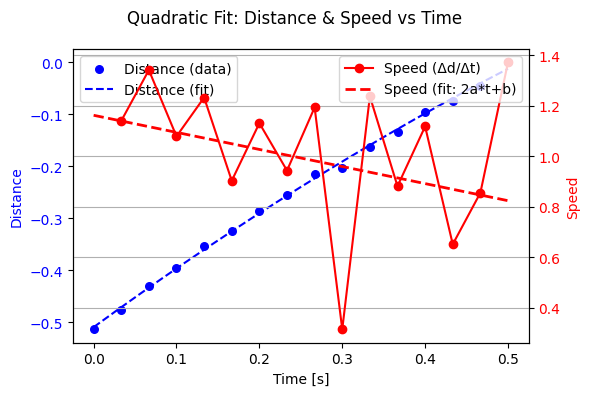

In [83]:
data_points_20251017_145944 = [
MovingPoint(time=0.0, distance=-0.5134748282803577),
MovingPoint(time=0.03333333333333144, distance=-0.47544321429315817),
MovingPoint(time=0.06666666666666288, distance=-0.4307019224359515),
MovingPoint(time=0.09999999999999432, distance=-0.3947135478086449),
MovingPoint(time=0.13333333333333286, distance=-0.35359749732255846),
MovingPoint(time=0.1666666666666643, distance=-0.32347307418509447),
MovingPoint(time=0.19999999999999574, distance=-0.2857437182732934),
MovingPoint(time=0.23333333333332718, distance=-0.2542749985551053),
MovingPoint(time=0.2666666666666657, distance=-0.214470032760488),
MovingPoint(time=0.29999999999999716, distance=-0.20397739701948456),
MovingPoint(time=0.3333333333333286, distance=-0.1627161740380837),
MovingPoint(time=0.36666666666666714, distance=-0.13331189841207103),
MovingPoint(time=0.3999999999999986, distance=-0.09601837993501322),
MovingPoint(time=0.43333333333333, distance=-0.07429051809921675),
MovingPoint(time=0.46666666666666146, distance=-0.045760024141414155),
MovingPoint(time=0.5, distance=-0.0),
]
plot_quadratic_fit(data_points_20251017_145944)

2次関数: distance = -0.309543 * time^2 + 1.174520 * time + -0.543784
摩擦係数: mu=0.063108 最終速度(AtNearCup): v= 0.844341 到達距離(FromNearCup): s=1.15
i=1 time= 0.100000 distance=-0.42 dt=0.100000 dd=0.124053 v=1.240534
i=2 time= 0.133333 distance=-0.39 dt=0.033333 dd=0.035971 v=1.079115
i=3 time= 0.166667 distance=-0.36 dt=0.033333 dd=0.028830 v=0.864910
i=4 time= 0.200000 distance=-0.32 dt=0.033333 dd=0.035044 v=1.051322
i=5 time= 0.233333 distance=-0.29 dt=0.033333 dd=0.032168 v=0.965030
i=6 time= 0.266667 distance=-0.25 dt=0.033333 dd=0.041585 v=1.247549
i=7 time= 0.300000 distance=-0.21 dt=0.033333 dd=0.037192 v=1.115771
i=8 time= 0.333333 distance=-0.19 dt=0.033333 dd=0.023853 v=0.715585
i=9 time= 0.366667 distance=-0.15 dt=0.033333 dd=0.037856 v=1.135679
i=10 time= 0.400000 distance=-0.13 dt=0.033333 dd=0.020728 v=0.621829
i=11 time= 0.433333 distance=-0.09 dt=0.033333 dd=0.038974 v=1.169226
i=12 time= 0.466667 distance=-0.07 dt=0.033333 dd=0.023434 v=0.703013
i=13 time= 0.500000 distance=-

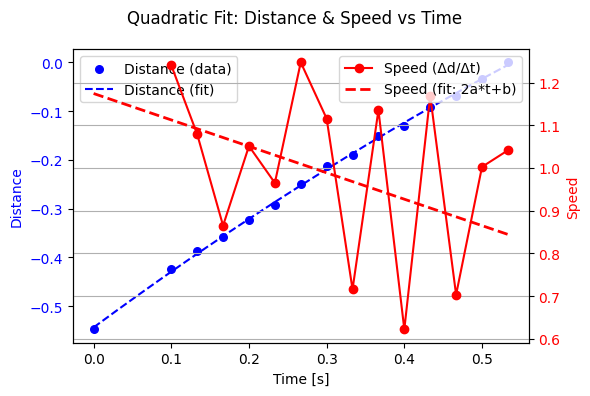

2次関数: distance = 0.289661 * time^2 + 0.843585 * time + -0.213842
摩擦係数: mu=-0.059054 最終速度(AtNearCup): v= 0.978760 到達距離(FromNearCup): s=-1.65
i=1 time= 0.033333 distance=-0.19 dt=0.033333 dd=0.023853 v=0.715585
i=2 time= 0.066667 distance=-0.15 dt=0.033333 dd=0.037856 v=1.135679
i=3 time= 0.100000 distance=-0.13 dt=0.033333 dd=0.020728 v=0.621829
i=4 time= 0.133333 distance=-0.09 dt=0.033333 dd=0.038974 v=1.169226
i=5 time= 0.166667 distance=-0.07 dt=0.033333 dd=0.023434 v=0.703013
i=6 time= 0.200000 distance=-0.03 dt=0.033333 dd=0.033419 v=1.002579
i=7 time= 0.233333 distance=-0.00 dt=0.033333 dd=0.034715 v=1.041440


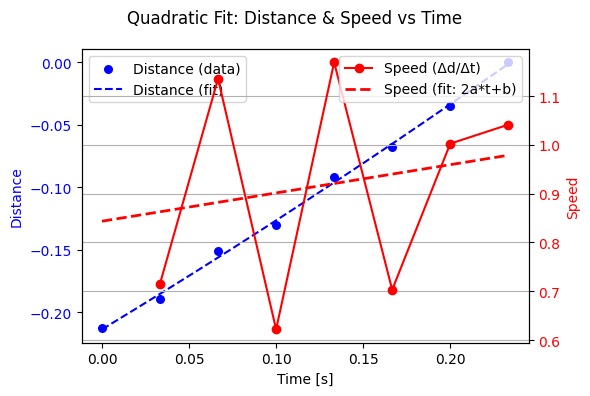

In [94]:
# Putt2
data_points_20251017_150426 = [
MovingPoint(time=0.0, distance=-0.5478216627532067),
MovingPoint(time=0.10000000000000142, distance=-0.423768226023725),
MovingPoint(time=0.13333333333333286, distance=-0.3877977242017459),
MovingPoint(time=0.1666666666666643, distance=-0.3589673855714884),
MovingPoint(time=0.19999999999999574, distance=-0.3239233261551978),
MovingPoint(time=0.23333333333333428, distance=-0.2917556741045065),
MovingPoint(time=0.2666666666666657, distance=-0.2501707162638862),
MovingPoint(time=0.29999999999999716, distance=-0.2129783479728813),
MovingPoint(time=0.3333333333333286, distance=-0.1891255155749346),
MovingPoint(time=0.36666666666666714, distance=-0.15126955878887852),
MovingPoint(time=0.3999999999999986, distance=-0.13054192219805),
MovingPoint(time=0.43333333333333, distance=-0.09156771670712183),
MovingPoint(time=0.46666666666666146, distance=-0.06813396160862419),
MovingPoint(time=0.5, distance=-0.03471467306792662),
MovingPoint(time=0.5333333333333314, distance=-0.0),
]

data_points_fit_20251017_150426 = [
MovingPoint(time=0.0, distance=-0.2129783479728813),
MovingPoint(time=0.03333333333333144, distance=-0.1891255155749346),
MovingPoint(time=0.06666666666666998, distance=-0.15126955878887852),
MovingPoint(time=0.10000000000000142, distance=-0.13054192219805),
MovingPoint(time=0.13333333333333286, distance=-0.09156771670712183),
MovingPoint(time=0.1666666666666643, distance=-0.06813396160862419),
MovingPoint(time=0.20000000000000284, distance=-0.03471467306792662),
MovingPoint(time=0.23333333333333428, distance=-0.0),
]
plot_quadratic_fit(data_points_20251017_150426)
plot_quadratic_fit(data_points_fit_20251017_150426)

In [96]:
data_points_20251017_160928 = [
MovingPoint(time=0.0, distance=-0.5478216627532067),
MovingPoint(time=0.10000000000000142, distance=-0.423768226023725),
MovingPoint(time=0.13333333333333286, distance=-0.3877977242017459),
MovingPoint(time=0.1666666666666643, distance=-0.3589673855714884),
MovingPoint(time=0.19999999999999574, distance=-0.3239233261551978),
MovingPoint(time=0.23333333333333428, distance=-0.2917556741045065),
MovingPoint(time=0.2666666666666657, distance=-0.2501707162638862),
MovingPoint(time=0.29999999999999716, distance=-0.2129783479728813),
MovingPoint(time=0.3333333333333286, distance=-0.1891255155749346),
MovingPoint(time=0.36666666666666714, distance=-0.15126955878887852),
MovingPoint(time=0.3999999999999986, distance=-0.13054192219805),
MovingPoint(time=0.43333333333333, distance=-0.09156771670712183),
MovingPoint(time=0.46666666666666146, distance=-0.06813396160862419),
MovingPoint(time=0.5, distance=-0.03471467306792662),
MovingPoint(time=0.5333333333333314, distance=-0.0),
]
data_points_fit_20251017_160928 = [
MovingPoint(time=0.0, distance=-0.423768226023725),
MovingPoint(time=0.03333333333333144, distance=-0.3877977242017459),
MovingPoint(time=0.06666666666666288, distance=-0.3589673855714884),
MovingPoint(time=0.09999999999999432, distance=-0.3239233261551978),
MovingPoint(time=0.13333333333333286, distance=-0.2917556741045065),
MovingPoint(time=0.1666666666666643, distance=-0.2501707162638862),
MovingPoint(time=0.19999999999999574, distance=-0.2129783479728813),
MovingPoint(time=0.23333333333332718, distance=-0.1891255155749346),
MovingPoint(time=0.2666666666666657, distance=-0.15126955878887852),
MovingPoint(time=0.29999999999999716, distance=-0.13054192219805),
MovingPoint(time=0.3333333333333286, distance=-0.09156771670712183),
MovingPoint(time=0.36666666666666003, distance=-0.06813396160862419),
MovingPoint(time=0.3999999999999986, distance=-0.03471467306792662),
MovingPoint(time=0.43333333333333, distance=-0.0),
]
#-------- FitResult --------
#a=-0.21720752837249674, b=1.0675418763785751, c=-0.42537616112630683
#endPosition=(-0.018359820299909797, 0.49339462356896296, 0.49373610113926614)
#endBallSpeed=(0.8792953517890794)
#ballDirection=-90.03315031158068 deg
#mu=0.044282880402140005
#estimatedMu=0.044282880402140005
#----------------------------

2次関数: distance = -0.440343 * time^2 + 1.203358 * time + -0.467861
摩擦係数: mu=0.089774 最終速度(AtNearCup): v= 1.614344 到達距離(FromNearCup): s=2.96
i=1 time= 0.066667 distance=-0.39 dt=0.066667 dd=0.084737 v=1.271056
i=2 time= 0.100000 distance=-0.36 dt=0.033333 dd=0.032934 v=0.988016
i=3 time= 0.133333 distance=-0.30 dt=0.033333 dd=0.051980 v=1.559388
i=4 time= 0.166667 distance=-0.28 dt=0.033333 dd=0.026781 v=0.803432
i=5 time= 0.200000 distance=-0.24 dt=0.033333 dd=0.039491 v=1.184721
i=6 time= 0.233333 distance=-0.21 dt=0.033333 dd=0.025313 v=0.759395
i=7 time= 0.266667 distance=-0.19 dt=0.033333 dd=0.023146 v=0.694389
i=8 time= 0.300000 distance=-0.15 dt=0.033333 dd=0.040731 v=1.221923
i=9 time= 0.333333 distance=-0.12 dt=0.033333 dd=0.025248 v=0.757435
i=10 time= 0.366667 distance=-0.09 dt=0.033333 dd=0.034963 v=1.048904
i=11 time= 0.400000 distance=-0.05 dt=0.033333 dd=0.033586 v=1.007576
i=12 time= 0.433333 distance=-0.03 dt=0.033333 dd=0.027987 v=0.839617
i=13 time= 0.466667 distance=-

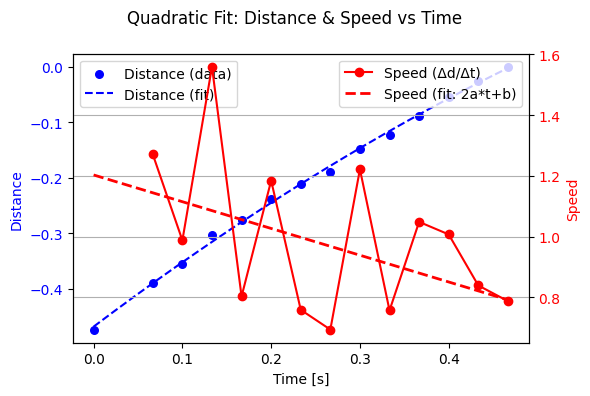

2次関数: distance = -0.205700 * time^2 + 0.981013 * time + -0.215445
摩擦係数: mu=0.041937 最終速度(AtNearCup): v= 1.077006 到達距離(FromNearCup): s=2.82
i=1 time= 0.033333 distance=-0.19 dt=0.033333 dd=0.023146 v=0.694389
i=2 time= 0.066667 distance=-0.15 dt=0.033333 dd=0.040731 v=1.221923
i=3 time= 0.100000 distance=-0.12 dt=0.033333 dd=0.025248 v=0.757435
i=4 time= 0.133333 distance=-0.09 dt=0.033333 dd=0.034963 v=1.048904
i=5 time= 0.166667 distance=-0.05 dt=0.033333 dd=0.033586 v=1.007576
i=6 time= 0.200000 distance=-0.03 dt=0.033333 dd=0.027987 v=0.839617
i=7 time= 0.233333 distance=-0.00 dt=0.033333 dd=0.026269 v=0.788078


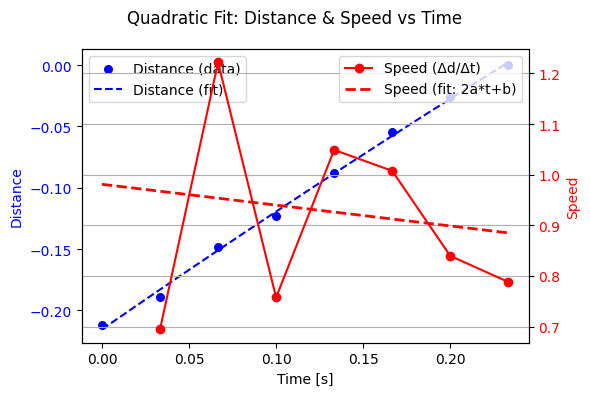

In [85]:
# Putt3
data_points_20251017_151520 = [
MovingPoint(time=0.0, distance=-0.47316617182298326),
MovingPoint(time=0.06666666666666288, distance=-0.3884291019946724),
MovingPoint(time=0.09999999999999432, distance=-0.3554952311617416),
MovingPoint(time=0.13333333333332575, distance=-0.3035156275922817),
MovingPoint(time=0.1666666666666572, distance=-0.2767345533570576),
MovingPoint(time=0.19999999999998863, distance=-0.2372438552673793),
MovingPoint(time=0.23333333333333428, distance=-0.21193068346107385),
MovingPoint(time=0.2666666666666657, distance=-0.18878439603447733),
MovingPoint(time=0.29999999999999716, distance=-0.14805363529912388),
MovingPoint(time=0.3333333333333286, distance=-0.1228058140002262),
MovingPoint(time=0.36666666666666003, distance=-0.08784235541933315),
MovingPoint(time=0.3999999999999915, distance=-0.05425647243721319),
MovingPoint(time=0.4333333333333229, distance=-0.026269253564607183),
MovingPoint(time=0.46666666666666856, distance=-0.0),
]
data_points_fit_20251017_151520 = [
MovingPoint(time=0.0, distance=-0.21193068346107385),
MovingPoint(time=0.03333333333333144, distance=-0.18878439603447733),
MovingPoint(time=0.06666666666666288, distance=-0.14805363529912388),
MovingPoint(time=0.09999999999999432, distance=-0.1228058140002262),
MovingPoint(time=0.13333333333332575, distance=-0.08784235541933315),
MovingPoint(time=0.1666666666666572, distance=-0.05425647243721319),
MovingPoint(time=0.19999999999998863, distance=-0.026269253564607183),
MovingPoint(time=0.23333333333333428, distance=-0.0),
]
#-------- FitResult --------
#a=-0.20569962599938996, b=0.9810128093082656, c=-0.21544460574631188
#endPosition=(-0.02254463002912681, 0.48294222197761466, 0.4834681479806357)
#endBallSpeed=(0.8850196505085499)
#ballDirection=-90.70266439278299 deg
#mu=0.041936722935655445
#estimatedMu=0.041936722935655445

plot_quadratic_fit(data_points_20251017_151520)
quadratic_fit(data_points_fit_20251017_151520)

2次関数: distance = -0.598892 * time^2 + 1.504346 * time + -0.748261
摩擦係数: mu=0.122098 最終速度(AtNearCup): v= 2.302869 到達距離(FromNearCup): s=4.43
i=1 time= 0.100000 distance=-0.57 dt=0.100000 dd=0.202716 v=2.027158
i=2 time= 0.166667 distance=-0.51 dt=0.066667 dd=0.064249 v=0.963730
i=3 time= 0.200000 distance=-0.46 dt=0.033333 dd=0.047316 v=1.419492
i=4 time= 0.266667 distance=-0.40 dt=0.066667 dd=0.064256 v=0.963836
i=5 time= 0.300000 distance=-0.35 dt=0.033333 dd=0.044326 v=1.329783
i=6 time= 0.333333 distance=-0.32 dt=0.033333 dd=0.033417 v=1.002505
i=7 time= 0.366667 distance=-0.28 dt=0.033333 dd=0.036727 v=1.101802
i=8 time= 0.400000 distance=-0.25 dt=0.033333 dd=0.033773 v=1.013184
i=9 time= 0.433333 distance=-0.21 dt=0.033333 dd=0.033285 v=0.998540
i=10 time= 0.466667 distance=-0.17 dt=0.033333 dd=0.041508 v=1.245252
i=11 time= 0.500000 distance=-0.15 dt=0.033333 dd=0.022339 v=0.670177
i=12 time= 0.533333 distance=-0.12 dt=0.033333 dd=0.028689 v=0.860657
i=13 time= 0.566667 distance=-

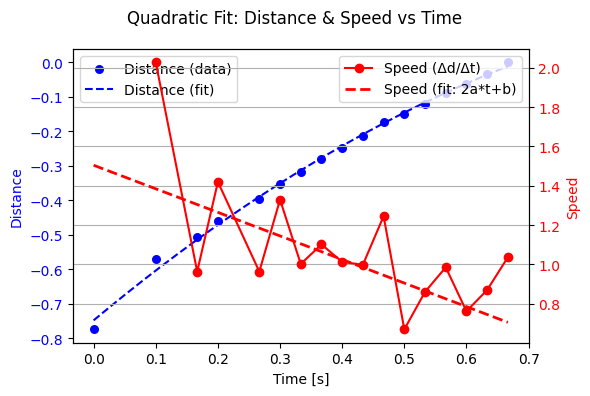

2次関数: distance = -0.387440 * time^2 + 1.195812 * time + -0.505370
摩擦係数: mu=0.078989 最終速度(AtNearCup): v= 1.583253 到達距離(FromNearCup): s=3.23
i=1 time= 0.033333 distance=-0.46 dt=0.033333 dd=0.047316 v=1.419492
i=2 time= 0.100000 distance=-0.40 dt=0.066667 dd=0.064256 v=0.963836
i=3 time= 0.133333 distance=-0.35 dt=0.033333 dd=0.044326 v=1.329783
i=4 time= 0.166667 distance=-0.32 dt=0.033333 dd=0.033417 v=1.002505
i=5 time= 0.200000 distance=-0.28 dt=0.033333 dd=0.036727 v=1.101802
i=6 time= 0.233333 distance=-0.25 dt=0.033333 dd=0.033773 v=1.013184
i=7 time= 0.266667 distance=-0.21 dt=0.033333 dd=0.033285 v=0.998540
i=8 time= 0.300000 distance=-0.17 dt=0.033333 dd=0.041508 v=1.245252
i=9 time= 0.333333 distance=-0.15 dt=0.033333 dd=0.022339 v=0.670177
i=10 time= 0.366667 distance=-0.12 dt=0.033333 dd=0.028689 v=0.860657
i=11 time= 0.400000 distance=-0.09 dt=0.033333 dd=0.032851 v=0.985534
i=12 time= 0.433333 distance=-0.06 dt=0.033333 dd=0.025411 v=0.762319
i=13 time= 0.466667 distance=-

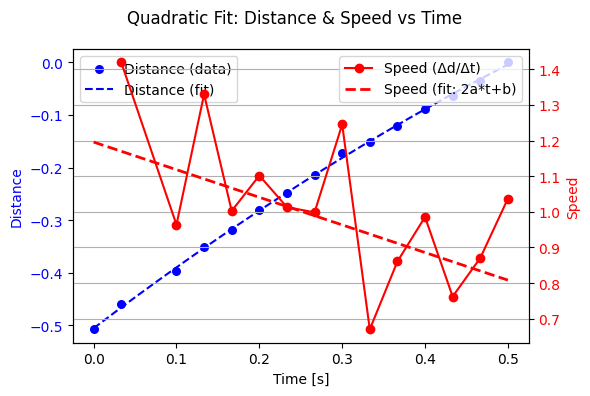

In [92]:
#Putt1

data_points_20251017_152232 = [
MovingPoint(time=0.0, distance=-0.7744392028882643),
MovingPoint(time=0.10000000000000142, distance=-0.5717233864948341),
MovingPoint(time=0.1666666666666643, distance=-0.5074746973043552),
MovingPoint(time=0.19999999999999574, distance=-0.4601582827653731),
MovingPoint(time=0.2666666666666657, distance=-0.3959025407283786),
MovingPoint(time=0.29999999999999716, distance=-0.351576452463463),
MovingPoint(time=0.3333333333333286, distance=-0.3181596042776145),
MovingPoint(time=0.36666666666666714, distance=-0.28143288538498146),
MovingPoint(time=0.3999999999999986, distance=-0.24766009392350558),
MovingPoint(time=0.43333333333333, distance=-0.2143754368729347),
MovingPoint(time=0.46666666666666856, distance=-0.17286703428273476),
MovingPoint(time=0.5, distance=-0.15052781611234622),
MovingPoint(time=0.5333333333333314, distance=-0.1218392466644385),
MovingPoint(time=0.5666666666666629, distance=-0.08898811386706515),
MovingPoint(time=0.6000000000000014, distance=-0.06357748142738631),
MovingPoint(time=0.6333333333333329, distance=-0.034565039989895546),
MovingPoint(time=0.6666666666666643, distance=-0.0),
]
data_points_fit_20251017_152232 = [
MovingPoint(time=0.0, distance=-0.5074746973043552),
MovingPoint(time=0.03333333333333144, distance=-0.4601582827653731),
MovingPoint(time=0.10000000000000142, distance=-0.3959025407283786),
MovingPoint(time=0.13333333333333286, distance=-0.351576452463463),
MovingPoint(time=0.1666666666666643, distance=-0.3181596042776145),
MovingPoint(time=0.20000000000000284, distance=-0.28143288538498146),
MovingPoint(time=0.23333333333333428, distance=-0.24766009392350558),
MovingPoint(time=0.2666666666666657, distance=-0.2143754368729347),
MovingPoint(time=0.30000000000000426, distance=-0.17286703428273476),
MovingPoint(time=0.3333333333333357, distance=-0.15052781611234622),
MovingPoint(time=0.36666666666666714, distance=-0.1218392466644385),
MovingPoint(time=0.3999999999999986, distance=-0.08898811386706515),
MovingPoint(time=0.4333333333333371, distance=-0.06357748142738631),
MovingPoint(time=0.46666666666666856, distance=-0.034565039989895546),
MovingPoint(time=0.5, distance=-0.0),
]
#-------- FitResult --------
#a=-0.3874401188608243, b=1.1958124215340045, c=-0.505369943613069
#endPosition=(-0.018027661502367166, 0.4791997225369131, 0.4795387061110901)
#endBallSpeed=(0.8083723026731802)
#ballDirection=-89.60583302517388 deg
#mu=0.07898881118467366
#estimatedMu=0.07
#----------------------------
plot_quadratic_fit(data_points_20251017_152232)
plot_quadratic_fit(data_points_fit_20251017_152232)

2次関数: distance = -0.309543 * time^2 + 1.174520 * time + -0.543784
摩擦係数: mu=0.063108 最終速度(AtNearCup): v= 0.844341 到達距離(FromNearCup): s=1.15
i=1 time= 0.100000 distance=-0.42 dt=0.100000 dd=0.124053 v=1.240534
i=2 time= 0.133333 distance=-0.39 dt=0.033333 dd=0.035971 v=1.079115
i=3 time= 0.166667 distance=-0.36 dt=0.033333 dd=0.028830 v=0.864910
i=4 time= 0.200000 distance=-0.32 dt=0.033333 dd=0.035044 v=1.051322
i=5 time= 0.233333 distance=-0.29 dt=0.033333 dd=0.032168 v=0.965030
i=6 time= 0.266667 distance=-0.25 dt=0.033333 dd=0.041585 v=1.247549
i=7 time= 0.300000 distance=-0.21 dt=0.033333 dd=0.037192 v=1.115771
i=8 time= 0.333333 distance=-0.19 dt=0.033333 dd=0.023853 v=0.715585
i=9 time= 0.366667 distance=-0.15 dt=0.033333 dd=0.037856 v=1.135679
i=10 time= 0.400000 distance=-0.13 dt=0.033333 dd=0.020728 v=0.621829
i=11 time= 0.433333 distance=-0.09 dt=0.033333 dd=0.038974 v=1.169226
i=12 time= 0.466667 distance=-0.07 dt=0.033333 dd=0.023434 v=0.703013
i=13 time= 0.500000 distance=-

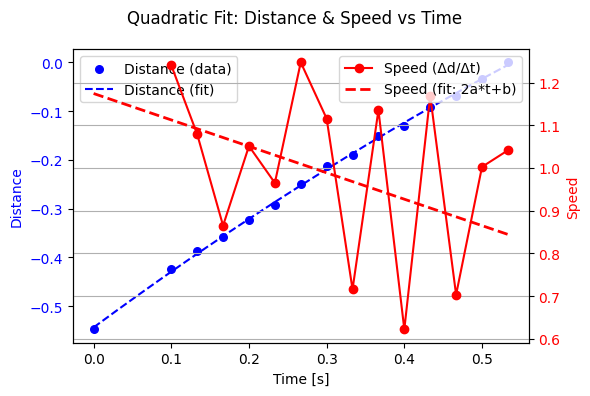

2次関数: distance = -0.217208 * time^2 + 1.067542 * time + -0.425376
摩擦係数: mu=0.044283 最終速度(AtNearCup): v= 0.879295 到達距離(FromNearCup): s=1.78
i=1 time= 0.033333 distance=-0.39 dt=0.033333 dd=0.035971 v=1.079115
i=2 time= 0.066667 distance=-0.36 dt=0.033333 dd=0.028830 v=0.864910
i=3 time= 0.100000 distance=-0.32 dt=0.033333 dd=0.035044 v=1.051322
i=4 time= 0.133333 distance=-0.29 dt=0.033333 dd=0.032168 v=0.965030
i=5 time= 0.166667 distance=-0.25 dt=0.033333 dd=0.041585 v=1.247549
i=6 time= 0.200000 distance=-0.21 dt=0.033333 dd=0.037192 v=1.115771
i=7 time= 0.233333 distance=-0.19 dt=0.033333 dd=0.023853 v=0.715585
i=8 time= 0.266667 distance=-0.15 dt=0.033333 dd=0.037856 v=1.135679
i=9 time= 0.300000 distance=-0.13 dt=0.033333 dd=0.020728 v=0.621829
i=10 time= 0.333333 distance=-0.09 dt=0.033333 dd=0.038974 v=1.169226
i=11 time= 0.366667 distance=-0.07 dt=0.033333 dd=0.023434 v=0.703013
i=12 time= 0.400000 distance=-0.03 dt=0.033333 dd=0.033419 v=1.002579
i=13 time= 0.433333 distance=-

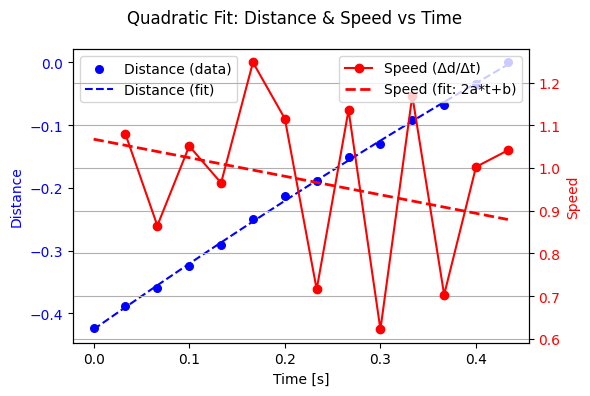

In [100]:

data_points_20251017_160928 = [
MovingPoint(time=0.0, distance=-0.5478216627532067),
MovingPoint(time=0.10000000000000142, distance=-0.423768226023725),
MovingPoint(time=0.13333333333333286, distance=-0.3877977242017459),
MovingPoint(time=0.1666666666666643, distance=-0.3589673855714884),
MovingPoint(time=0.19999999999999574, distance=-0.3239233261551978),
MovingPoint(time=0.23333333333333428, distance=-0.2917556741045065),
MovingPoint(time=0.2666666666666657, distance=-0.2501707162638862),
MovingPoint(time=0.29999999999999716, distance=-0.2129783479728813),
MovingPoint(time=0.3333333333333286, distance=-0.1891255155749346),
MovingPoint(time=0.36666666666666714, distance=-0.15126955878887852),
MovingPoint(time=0.3999999999999986, distance=-0.13054192219805),
MovingPoint(time=0.43333333333333, distance=-0.09156771670712183),
MovingPoint(time=0.46666666666666146, distance=-0.06813396160862419),
MovingPoint(time=0.5, distance=-0.03471467306792662),
MovingPoint(time=0.5333333333333314, distance=-0.0),
]
data_points_fit_20251017_160928 = [
MovingPoint(time=0.0, distance=-0.423768226023725),
MovingPoint(time=0.03333333333333144, distance=-0.3877977242017459),
MovingPoint(time=0.06666666666666288, distance=-0.3589673855714884),
MovingPoint(time=0.09999999999999432, distance=-0.3239233261551978),
MovingPoint(time=0.13333333333333286, distance=-0.2917556741045065),
MovingPoint(time=0.1666666666666643, distance=-0.2501707162638862),
MovingPoint(time=0.19999999999999574, distance=-0.2129783479728813),
MovingPoint(time=0.23333333333332718, distance=-0.1891255155749346),
MovingPoint(time=0.2666666666666657, distance=-0.15126955878887852),
MovingPoint(time=0.29999999999999716, distance=-0.13054192219805),
MovingPoint(time=0.3333333333333286, distance=-0.09156771670712183),
MovingPoint(time=0.36666666666666003, distance=-0.06813396160862419),
MovingPoint(time=0.3999999999999986, distance=-0.03471467306792662),
MovingPoint(time=0.43333333333333, distance=-0.0),
]
#-------- FitResult --------
#a=-0.21720752837249674, b=1.0675418763785751, c=-0.42537616112630683
#endPosition=(-0.018359820299909797, 0.49339462356896296, 0.49373610113926614)
#endBallSpeed=(0.8792953517890794)
#ballDirection=-90.03315031158068 deg
#mu=0.044282880402140005
#estimatedMu=0.044282880402140005
#----------------------------
plot_quadratic_fit(data_points_20251017_160928)
plot_quadratic_fit(data_points_fit_20251017_160928)

2次関数: distance = -0.263222 * time^2 + 1.155947 * time + -0.560354
摩擦係数: mu=0.053664 最終速度(AtNearCup): v= 0.866403 到達距離(FromNearCup): s=1.43
i=1 time= 0.100000 distance=-0.45 dt=0.100000 dd=0.111566 v=1.115657
i=2 time= 0.183333 distance=-0.36 dt=0.083333 dd=0.088913 v=1.066961
i=3 time= 0.250000 distance=-0.29 dt=0.066667 dd=0.067212 v=1.008176
i=4 time= 0.316667 distance=-0.21 dt=0.066667 dd=0.078777 v=1.181660
i=5 time= 0.350000 distance=-0.19 dt=0.033333 dd=0.023853 v=0.715585
i=6 time= 0.400000 distance=-0.14 dt=0.050000 dd=0.050912 v=1.018247
i=7 time= 0.450000 distance=-0.09 dt=0.050000 dd=0.046645 v=0.932909
i=8 time= 0.483333 distance=-0.07 dt=0.033333 dd=0.023434 v=0.703013
i=9 time= 0.500000 distance=-0.05 dt=0.016667 dd=0.016876 v=1.012574
i=10 time= 0.516667 distance=-0.03 dt=0.016667 dd=0.016543 v=0.992584
i=11 time= 0.550000 distance=-0.00 dt=0.033333 dd=0.034715 v=1.041440


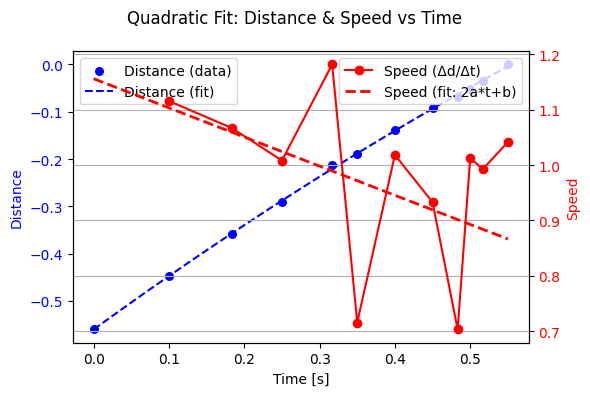

2次関数: distance = -0.287497 * time^2 + 1.116237 * time + -0.448719
摩擦係数: mu=0.058613 最終速度(AtNearCup): v= 0.857490 到達距離(FromNearCup): s=1.28
i=1 time= 0.083333 distance=-0.36 dt=0.083333 dd=0.088913 v=1.066961
i=2 time= 0.150000 distance=-0.29 dt=0.066667 dd=0.067212 v=1.008176
i=3 time= 0.216667 distance=-0.21 dt=0.066667 dd=0.078777 v=1.181660
i=4 time= 0.250000 distance=-0.19 dt=0.033333 dd=0.023853 v=0.715585
i=5 time= 0.300000 distance=-0.14 dt=0.050000 dd=0.050912 v=1.018247
i=6 time= 0.350000 distance=-0.09 dt=0.050000 dd=0.046645 v=0.932909
i=7 time= 0.383333 distance=-0.07 dt=0.033333 dd=0.023434 v=0.703013
i=8 time= 0.400000 distance=-0.05 dt=0.016667 dd=0.016876 v=1.012574
i=9 time= 0.416667 distance=-0.03 dt=0.016667 dd=0.016543 v=0.992584
i=10 time= 0.450000 distance=-0.00 dt=0.033333 dd=0.034715 v=1.041440


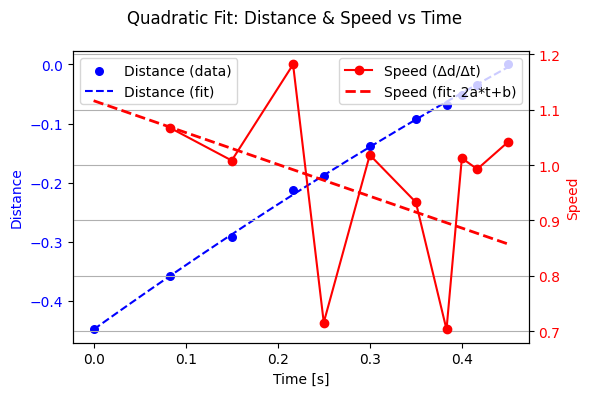

In [102]:
data_points_20251017_162849 = [
MovingPoint(time=0.0, distance=-0.5594465118975956),
MovingPoint(time=0.09999999999999432, distance=-0.4478808260325832),
MovingPoint(time=0.18333333333333002, distance=-0.3589673855714884),
MovingPoint(time=0.25, distance=-0.2917556741045065),
MovingPoint(time=0.3166666666666629, distance=-0.2129783479728813),
MovingPoint(time=0.3499999999999943, distance=-0.1891255155749346),
MovingPoint(time=0.3999999999999986, distance=-0.13821318608733965),
MovingPoint(time=0.44999999999999574, distance=-0.09156771670712183),
MovingPoint(time=0.4833333333333272, distance=-0.06813396160862419),
MovingPoint(time=0.5, distance=-0.05125773171819783),
MovingPoint(time=0.5166666666666657, distance=-0.03471467306792662),
MovingPoint(time=0.5499999999999972, distance=-0.0),
]
data_points_fit_20251017_162849 = [
MovingPoint(time=0.0, distance=-0.4478808260325832),
MovingPoint(time=0.0833333333333357, distance=-0.3589673855714884),
MovingPoint(time=0.15000000000000568, distance=-0.2917556741045065),
MovingPoint(time=0.21666666666666856, distance=-0.2129783479728813),
MovingPoint(time=0.25, distance=-0.1891255155749346),
MovingPoint(time=0.30000000000000426, distance=-0.13821318608733965),
MovingPoint(time=0.3500000000000014, distance=-0.09156771670712183),
MovingPoint(time=0.38333333333333286, distance=-0.06813396160862419),
MovingPoint(time=0.4000000000000057, distance=-0.05125773171819783),
MovingPoint(time=0.4166666666666714, distance=-0.03471467306792662),
MovingPoint(time=0.45000000000000284, distance=-0.0),
]
#-------- FitResult --------
#a=-0.2874970130669179, b=1.1162372423899714, c=-0.4487188234231
#endPosition=(-0.018342949197648378, 0.48429671563950644, 0.4846439647457507)
#endBallSpeed=(0.8574899306297437)
#ballDirection=-89.92745803948158 deg
#mu=0.05861305057429518
#estimatedMu=0.05861305057429518
#----------------------------
plot_quadratic_fit(data_points_20251017_162849)
plot_quadratic_fit(data_points_fit_20251017_162849)

2次関数: distance = -0.504294 * time^2 + 0.808033 * time + -0.113898
摩擦係数: mu=0.102812 最終速度(AtNearCup): v= 0.648280 到達距離(FromNearCup): s=0.42
i=1 time= 0.025009 distance=-0.09 dt=0.025009 dd=0.021832 v=0.872939
i=2 time= 0.058355 distance=-0.07 dt=0.033346 dd=0.022111 v=0.663095
i=3 time= 0.083364 distance=-0.05 dt=0.025009 dd=0.018358 v=0.734043
i=4 time= 0.108374 distance=-0.03 dt=0.025010 dd=0.021589 v=0.863232
i=5 time= 0.133383 distance=-0.01 dt=0.025009 dd=0.016940 v=0.677347
i=6 time= 0.158393 distance=-0.00 dt=0.025010 dd=0.013354 v=0.533975


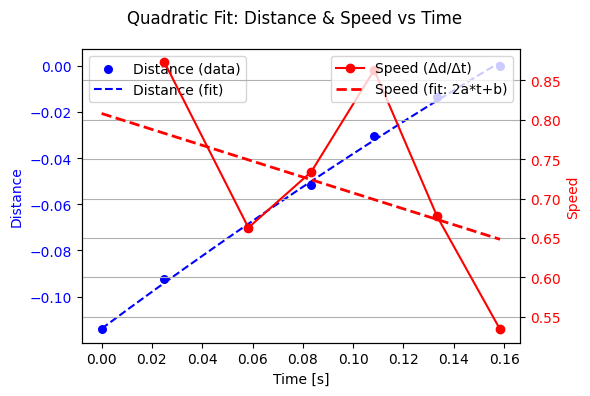

2次関数: distance = -0.504294 * time^2 + 0.808033 * time + -0.113898
摩擦係数: mu=0.102812 最終速度(AtNearCup): v= 0.648280 到達距離(FromNearCup): s=0.42
i=1 time= 0.025009 distance=-0.09 dt=0.025009 dd=0.021832 v=0.872939
i=2 time= 0.058355 distance=-0.07 dt=0.033346 dd=0.022111 v=0.663095
i=3 time= 0.083364 distance=-0.05 dt=0.025009 dd=0.018358 v=0.734043
i=4 time= 0.108374 distance=-0.03 dt=0.025010 dd=0.021589 v=0.863232
i=5 time= 0.133383 distance=-0.01 dt=0.025009 dd=0.016940 v=0.677347
i=6 time= 0.158393 distance=-0.00 dt=0.025010 dd=0.013354 v=0.533975


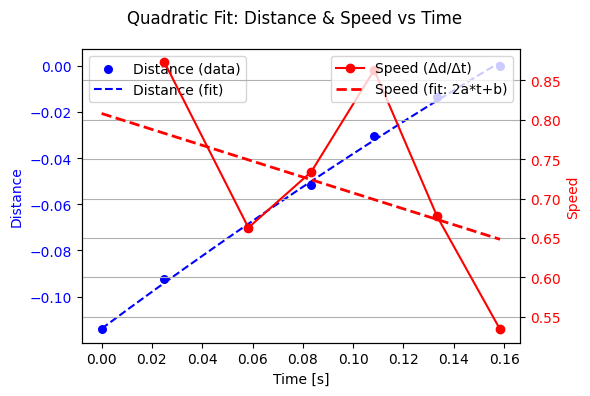

In [111]:
#120fsp
data_points_20251017_180338 = [
MovingPoint(time=0.0, distance=-0.11418451362709417),
MovingPoint(time=0.02500929198868107, distance=-0.09235292134720732),
MovingPoint(time=0.05835516699880827, distance=-0.07024144600974686),
MovingPoint(time=0.08336449999478646, distance=-0.05188352617373747),
MovingPoint(time=0.10837400000309572, distance=-0.03029452358968124),
MovingPoint(time=0.1333834169927286, distance=-0.013354459962864757),
MovingPoint(time=0.15839291700103786, distance=-0.0),
]
data_points_fit_20251017_180338 = [
MovingPoint(time=0.0, distance=-0.11418451362709417),
MovingPoint(time=0.02500929198868107, distance=-0.09235292134720732),
MovingPoint(time=0.05835516699880827, distance=-0.07024144600974686),
MovingPoint(time=0.08336449999478646, distance=-0.05188352617373747),
MovingPoint(time=0.10837400000309572, distance=-0.03029452358968124),
MovingPoint(time=0.1333834169927286, distance=-0.013354459962864757),
MovingPoint(time=0.15839291700103786, distance=-0.0),
]
#-------- FitResult --------
#a=-0.5042936033794653, b=0.8080328872870256, c=-0.11389777407594676
#endPosition=(0.010361298246080614, 0.4145303628843905, 0.41465983438766857)
#endBallSpeed=(0.6482798175585497)
#ballDirection=-85.16937165409631 deg
#mu=0.10281215155544653
#estimatedMu=0.07
#----------------------------
plot_quadratic_fit(data_points_20251017_180338)
plot_quadratic_fit(data_points_fit_20251017_180338)

2次関数: distance = -0.167395 * time^2 + 1.013165 * time + -0.356347
摩擦係数: mu=0.034127 最終速度(AtNearCup): v= 0.887569 到達距離(FromNearCup): s=2.35
i=1 time= 0.058356 distance=-0.30 dt=0.058356 dd=0.053905 v=0.923732
i=2 time= 0.091702 distance=-0.27 dt=0.033346 dd=0.030076 v=0.901917
i=3 time= 0.125049 distance=-0.23 dt=0.033347 dd=0.039387 v=1.181130
i=4 time= 0.158395 distance=-0.21 dt=0.033346 dd=0.024302 v=0.728789
i=5 time= 0.191742 distance=-0.17 dt=0.033346 dd=0.038131 v=1.143480
i=6 time= 0.225088 distance=-0.13 dt=0.033346 dd=0.037774 v=1.132791
i=7 time= 0.258434 distance=-0.11 dt=0.033346 dd=0.023836 v=0.714788
i=8 time= 0.291781 distance=-0.07 dt=0.033346 dd=0.032464 v=0.973534
i=9 time= 0.316790 distance=-0.05 dt=0.025010 dd=0.020292 v=0.811347
i=10 time= 0.341800 distance=-0.03 dt=0.025010 dd=0.021330 v=0.852850
i=11 time= 0.375146 distance=-0.00 dt=0.033346 dd=0.031764 v=0.952551


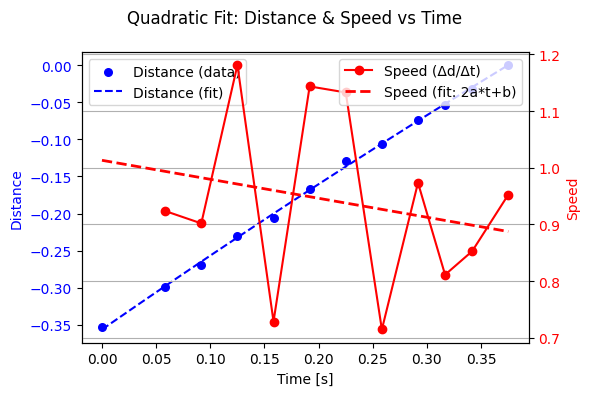

In [116]:
data_points120 = [
    MovingPoint(time=42.208268166999915, distance=-0.3532599016669939),
MovingPoint(time=42.26662429200951, distance=-0.29935450646361517),
MovingPoint(time=42.29997054200794, distance=-0.26927895131604745),
MovingPoint(time=42.33331712499785, distance=-0.22989230216123308),
MovingPoint(time=42.36666341700766, distance=-0.20558988328018404),
MovingPoint(time=42.40000983400387, distance=-0.1674589385954809),
MovingPoint(time=42.43335616700642, distance=-0.1296845251617748),
MovingPoint(time=42.46670250000898, distance=-0.1058489786830434),
MovingPoint(time=42.50004891700519, distance=-0.07338511868547178),
MovingPoint(time=42.525058583996724, distance=-0.05309360848570211),
MovingPoint(time=42.55006837499968, distance=-0.031764019365579536),
MovingPoint(time=42.58341462499811, distance=-0.0)
]
plot_quadratic_fit(data_points120)

2次関数: distance = -0.240182 * time^2 + 0.843108 * time + -0.341743
摩擦係数: mu=0.048967 最終速度(AtNearCup): v= 0.618937 到達距離(FromNearCup): s=0.80
i=1 time= 0.066667 distance=-0.28 dt=0.066667 dd=0.063533 v=0.952997
i=2 time= 0.100001 distance=-0.26 dt=0.033334 dd=0.026131 v=0.783916
i=3 time= 0.133334 distance=-0.23 dt=0.033333 dd=0.021551 v=0.646538
i=4 time= 0.166668 distance=-0.21 dt=0.033334 dd=0.025153 v=0.754593
i=5 time= 0.200001 distance=-0.18 dt=0.033333 dd=0.025913 v=0.777381
i=6 time= 0.233335 distance=-0.16 dt=0.033334 dd=0.021699 v=0.650963
i=7 time= 0.266668 distance=-0.13 dt=0.033333 dd=0.028142 v=0.844258
i=8 time= 0.300001 distance=-0.11 dt=0.033333 dd=0.025435 v=0.763061
i=9 time= 0.333335 distance=-0.09 dt=0.033334 dd=0.019910 v=0.597295
i=10 time= 0.366668 distance=-0.07 dt=0.033333 dd=0.022817 v=0.684501
i=11 time= 0.400002 distance=-0.04 dt=0.033334 dd=0.021026 v=0.630764
i=12 time= 0.433335 distance=-0.02 dt=0.033333 dd=0.023938 v=0.718142
i=13 time= 0.466669 distance=-

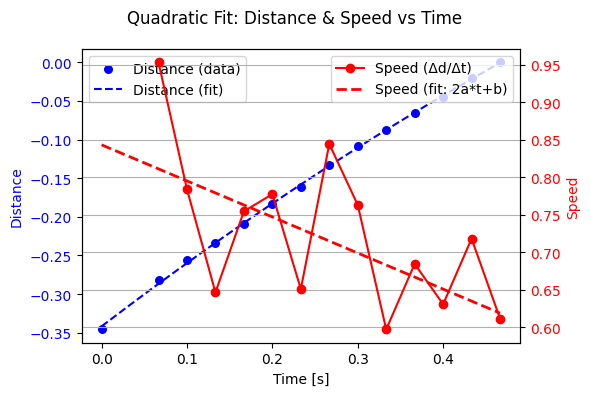

In [119]:
data_points_raw_20251017_183630 = [
MovingPoint(time=0.0, distance=-0.3456354440061212),
MovingPoint(time=0.06666700000641868, distance=-0.2821019699647632),
MovingPoint(time=0.10000054200645536, distance=-0.2559712770216865),
MovingPoint(time=0.13333404199511278, distance=-0.2344199181939328),
MovingPoint(time=0.16666754199832212, distance=-0.2092666907431456),
MovingPoint(time=0.2000010000047041, distance=-0.18335389484165177),
MovingPoint(time=0.23333458400156815, distance=-0.1616549560908255),
MovingPoint(time=0.26666804200795013, distance=-0.13351293026392994),
MovingPoint(time=0.30000141699565575, distance=-0.10807753770192059),
MovingPoint(time=0.33333500000298955, distance=-0.0881675567260347),
MovingPoint(time=0.3666684170020744, distance=-0.06535078353693444),
MovingPoint(time=0.40000204200623557, distance=-0.044325130420714474),
MovingPoint(time=0.4333354169939412, distance=-0.020387026138854698),
MovingPoint(time=0.46666887500032317, distance=-0.0),
]
plot_quadratic_fit(data_points_raw_20251017_183630)

2次関数: distance = -0.195522 * time^2 + 1.186459 * time + -0.406365
摩擦係数: mu=0.039862 最終速度(AtNearCup): v= 1.043076 到達距離(FromNearCup): s=2.78
i=1 time= 0.033334 distance=-0.36 dt=0.033334 dd=0.044904 v=1.347117
i=2 time= 0.066667 distance=-0.33 dt=0.033333 dd=0.036036 v=1.081078
i=3 time= 0.100001 distance=-0.29 dt=0.033334 dd=0.037217 v=1.116505
i=4 time= 0.133334 distance=-0.25 dt=0.033333 dd=0.040151 v=1.204540
i=5 time= 0.166668 distance=-0.22 dt=0.033333 dd=0.033081 v=0.992426
i=6 time= 0.200001 distance=-0.18 dt=0.033334 dd=0.041211 v=1.236310
i=7 time= 0.233335 distance=-0.14 dt=0.033334 dd=0.035951 v=1.078535
i=8 time= 0.266668 distance=-0.11 dt=0.033333 dd=0.034124 v=1.023715
i=9 time= 0.300002 distance=-0.07 dt=0.033334 dd=0.039487 v=1.184608
i=10 time= 0.333335 distance=-0.03 dt=0.033333 dd=0.037115 v=1.113446
i=11 time= 0.366669 distance=-0.00 dt=0.033334 dd=0.029363 v=0.880888


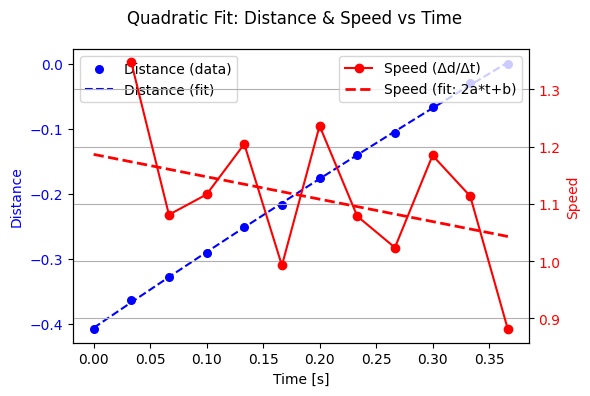

In [125]:
data_points_raw_20251017_184752 = [
MovingPoint(time=0.0, distance=-0.40864126933843276),
MovingPoint(time=0.033333583996864036, distance=-0.36373702540385566),
MovingPoint(time=0.06666704198869411, distance=-0.32770096806752763),
MovingPoint(time=0.10000062499602791, distance=-0.2904838672030515),
MovingPoint(time=0.13333408399194013, distance=-0.2503323928332155),
MovingPoint(time=0.16666754199832212, distance=-0.21725139341972102),
MovingPoint(time=0.2000010839983588, distance=-0.17604079792074306),
MovingPoint(time=0.23333458400156815, distance=-0.14008944308920893),
MovingPoint(time=0.26666808399022557, distance=-0.10596543479784962),
MovingPoint(time=0.300001625000732, distance=-0.06647824845281479),
MovingPoint(time=0.33333512498938944, distance=-0.029363190073266925),
MovingPoint(time=0.3666687499935506, distance=-0.0),
]
plot_quadratic_fit(data_points_raw_20251017_184752)

2次関数: distance = -0.267389 * time^2 + 1.330005 * time + -0.561300
摩擦係数: mu=0.054514 最終速度(AtNearCup): v= 1.080438 到達距離(FromNearCup): s=2.18
i=1 time= 0.066667 distance=-0.47 dt=0.066667 dd=0.097438 v=1.461548
i=2 time= 0.100001 distance=-0.43 dt=0.033334 dd=0.039043 v=1.171259
i=3 time= 0.133335 distance=-0.39 dt=0.033334 dd=0.040525 v=1.215722
i=4 time= 0.166669 distance=-0.35 dt=0.033334 dd=0.041488 v=1.244642
i=5 time= 0.200003 distance=-0.31 dt=0.033334 dd=0.037629 v=1.128858
i=6 time= 0.233336 distance=-0.27 dt=0.033334 dd=0.040440 v=1.213202
i=7 time= 0.266670 distance=-0.23 dt=0.033334 dd=0.042332 v=1.269940
i=8 time= 0.300004 distance=-0.19 dt=0.033334 dd=0.040352 v=1.210540
i=9 time= 0.333338 distance=-0.15 dt=0.033334 dd=0.039973 v=1.199167
i=10 time= 0.366671 distance=-0.11 dt=0.033334 dd=0.037162 v=1.114835
i=11 time= 0.400005 distance=-0.07 dt=0.033334 dd=0.037741 v=1.132225
i=12 time= 0.433339 distance=-0.03 dt=0.033334 dd=0.036876 v=1.106259
i=13 time= 0.466673 distance=-

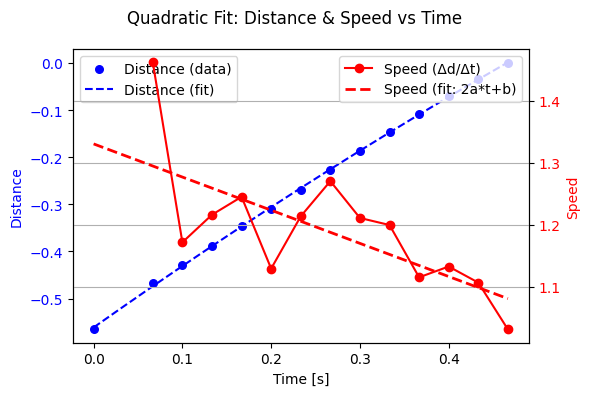

2次関数: distance = -0.507599 * time^2 + 1.269815 * time + -0.268539
摩擦係数: mu=0.103486 最終速度(AtNearCup): v= 1.032932 到達距離(FromNearCup): s=1.05
i=1 time= 0.033334 distance=-0.23 dt=0.033334 dd=0.042332 v=1.269940
i=2 time= 0.066668 distance=-0.19 dt=0.033334 dd=0.040352 v=1.210540
i=3 time= 0.100001 distance=-0.15 dt=0.033334 dd=0.039973 v=1.199167
i=4 time= 0.133335 distance=-0.11 dt=0.033334 dd=0.037162 v=1.114835
i=5 time= 0.166669 distance=-0.07 dt=0.033334 dd=0.037741 v=1.132225
i=6 time= 0.200003 distance=-0.03 dt=0.033334 dd=0.036876 v=1.106259
i=7 time= 0.233336 distance=-0.00 dt=0.033334 dd=0.034362 v=1.030851


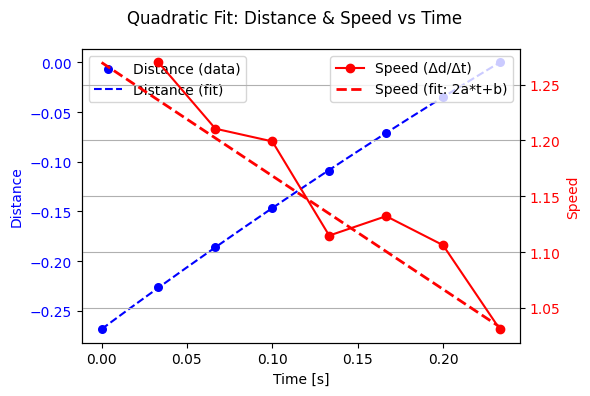

In [127]:
data_points_20251017_192048 = [
MovingPoint(time=0.0, distance=-0.5653603660431867),
MovingPoint(time=0.0666673749947222, distance=-0.46792279948298077),
MovingPoint(time=0.10000120800395962, distance=-0.42888024118252227),
MovingPoint(time=0.13333508299547248, distance=-0.388355509764168),
MovingPoint(time=0.16666874999646097, distance=-0.3468670394216753),
MovingPoint(time=0.20000250000157394, distance=-0.3092379645504546),
MovingPoint(time=0.23333616599848028, distance=-0.26879749581115964),
MovingPoint(time=0.26667012499819975, distance=-0.22646536902892647),
MovingPoint(time=0.3000037500023609, distance=-0.18611368124221656),
MovingPoint(time=0.3333376250084257, distance=-0.14614079321471704),
MovingPoint(time=0.36667133300215937, distance=-0.10897919702477724),
MovingPoint(time=0.4000051659968449, distance=-0.07123781055516037),
MovingPoint(time=0.43333879100100603, distance=-0.0343622018939312),
MovingPoint(time=0.4666726249997737, distance=-0.0),
]
data_points_fit_20251017_192048 = [
MovingPoint(time=0.0, distance=-0.26879749581115964),
MovingPoint(time=0.03333395899971947, distance=-0.22646536902892647),
MovingPoint(time=0.06666758400388062, distance=-0.18611368124221656),
MovingPoint(time=0.10000145900994539, distance=-0.14614079321471704),
MovingPoint(time=0.1333351670036791, distance=-0.10897919702477724),
MovingPoint(time=0.1666689999983646, distance=-0.07123781055516037),
MovingPoint(time=0.20000262500252575, distance=-0.0343622018939312),
MovingPoint(time=0.2333364590012934, distance=-0.0),
]
#-------- FitResult --------
#a=-0.5075993032586852, b=1.2698148408227867, c=-0.2685389291351083
#endPosition=(0.008540764045359063, 0.43755232715323017, 0.4376356745601138)
#endBallSpeed=(1.032931992794976)
#ballDirection=-92.59235763734057 deg
#mu=0.1034860964849511
#estimatedMu=0.07
#----------------------------
plot_quadratic_fit(data_points_20251017_192048)
plot_quadratic_fit(data_points_fit_20251017_192048)

2次関数: distance = -0.350781 * time^2 + 1.146507 * time + -0.487381
摩擦係数: mu=0.071515 最終速度(AtNearCup): v= 0.795721 到達距離(FromNearCup): s=0.90
i=1 time= 0.100002 distance=-0.37 dt=0.100002 dd=0.119314 v=1.193123
i=2 time= 0.133335 distance=-0.34 dt=0.033334 dd=0.035919 v=1.077545
i=3 time= 0.166669 distance=-0.30 dt=0.033334 dd=0.036936 v=1.108069
i=4 time= 0.200003 distance=-0.27 dt=0.033334 dd=0.026434 v=0.792994
i=5 time= 0.233337 distance=-0.24 dt=0.033334 dd=0.037307 v=1.119180
i=6 time= 0.266671 distance=-0.21 dt=0.033334 dd=0.022103 v=0.663083
i=7 time= 0.300004 distance=-0.18 dt=0.033334 dd=0.036657 v=1.099698
i=8 time= 0.333338 distance=-0.14 dt=0.033334 dd=0.037319 v=1.119564
i=9 time= 0.366672 distance=-0.12 dt=0.033334 dd=0.024649 v=0.739461
i=10 time= 0.400006 distance=-0.09 dt=0.033334 dd=0.024708 v=0.741216
i=11 time= 0.433340 distance=-0.06 dt=0.033334 dd=0.032574 v=0.977202
i=12 time= 0.466674 distance=-0.02 dt=0.033334 dd=0.034568 v=1.037013
i=13 time= 0.500007 distance=-

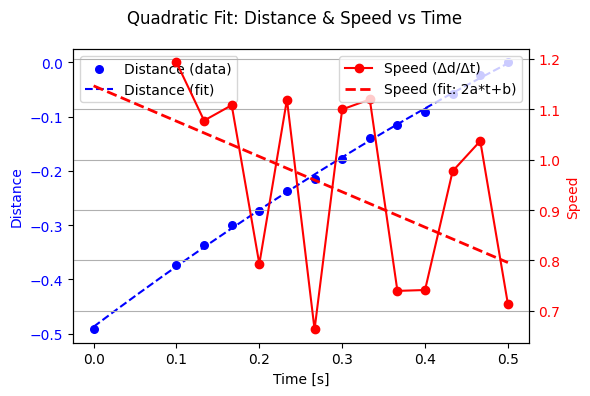

2次関数: distance = -0.206052 * time^2 + 0.973672 * time + -0.272615
摩擦係数: mu=0.042008 最終速度(AtNearCup): v= 0.850039 到達距離(FromNearCup): s=1.75
i=1 time= 0.033334 distance=-0.24 dt=0.033334 dd=0.037307 v=1.119180
i=2 time= 0.066668 distance=-0.21 dt=0.033334 dd=0.022103 v=0.663083
i=3 time= 0.100001 distance=-0.18 dt=0.033334 dd=0.036657 v=1.099698
i=4 time= 0.133335 distance=-0.14 dt=0.033334 dd=0.037319 v=1.119564
i=5 time= 0.166669 distance=-0.12 dt=0.033334 dd=0.024649 v=0.739461
i=6 time= 0.200003 distance=-0.09 dt=0.033334 dd=0.024708 v=0.741216
i=7 time= 0.233337 distance=-0.06 dt=0.033334 dd=0.032574 v=0.977202
i=8 time= 0.266671 distance=-0.02 dt=0.033334 dd=0.034568 v=1.037013
i=9 time= 0.300004 distance=-0.00 dt=0.033334 dd=0.023785 v=0.713537


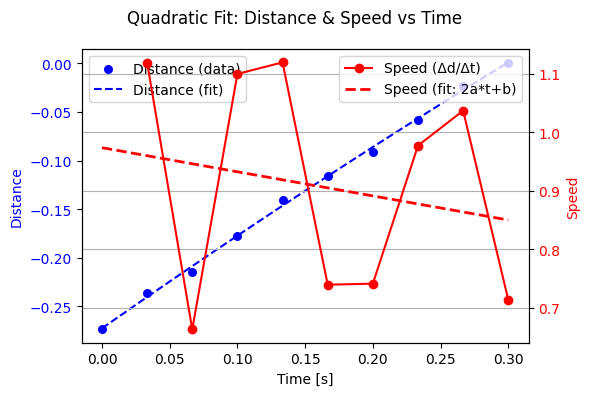

In [128]:
data_points_20251017_192456 = [
MovingPoint(time=0.0, distance=-0.49227182911258466),
MovingPoint(time=0.10000158399634529, distance=-0.37295768467199936),
MovingPoint(time=0.13333533400145825, distance=-0.337039063497022),
MovingPoint(time=0.16666925000026822, distance=-0.3001027983701825),
MovingPoint(time=0.20000312499178108, distance=-0.27366923215365707),
MovingPoint(time=0.2333369169937214, distance=-0.2363627023006731),
MovingPoint(time=0.2666707089956617, distance=-0.21425961718707603),
MovingPoint(time=0.30000445900077466, distance=-0.1776025425923656),
MovingPoint(time=0.33333837499958463, distance=-0.1402830909740936),
MovingPoint(time=0.3666721249901457, distance=-0.1156340912310129),
MovingPoint(time=0.4000060419930378, distance=-0.09092646001071462),
MovingPoint(time=0.4333399999886751, distance=-0.05835243948196569),
MovingPoint(time=0.4666738340019947, distance=-0.02378481910945649),
MovingPoint(time=0.500007499998901, distance=-0.0),
]
data_points_fit_20251017_192456 = [
MovingPoint(time=0.0, distance=-0.27366923215365707),
MovingPoint(time=0.03333379200194031, distance=-0.2363627023006731),
MovingPoint(time=0.06666758400388062, distance=-0.21425961718707603),
MovingPoint(time=0.10000133400899358, distance=-0.1776025425923656),
MovingPoint(time=0.13333525000780355, distance=-0.1402830909740936),
MovingPoint(time=0.1666689999983646, distance=-0.1156340912310129),
MovingPoint(time=0.20000291700125672, distance=-0.09092646001071462),
MovingPoint(time=0.23333687499689404, distance=-0.05835243948196569),
MovingPoint(time=0.2666707090102136, distance=-0.02378481910945649),
MovingPoint(time=0.30000437500711996, distance=-0.0),
]
#-------- FitResult --------
#a=-0.20605155817210918, b=0.9736720096723381, c=-0.27261526924347673
#endPosition=(-0.007395630677356894, 0.43421330979056555, 0.434276287347575)
#endBallSpeed=(0.8500392718150045)
#ballDirection=-94.81220518663977 deg
#mu=0.042008472614089534
#estimatedMu=0.042008472614089534
#----------------------------
plot_quadratic_fit(data_points_20251017_192456)
plot_quadratic_fit(data_points_fit_20251017_192456)

In [97]:
import numpy as np
from dataclasses import dataclass

@dataclass
class MovingPoint:
    distance: float
    time: float

# 重力加速度 (m/s^2)
g = 9.8

# サンプルデータ（距離[m], 時間[s]）
data_points = [
    MovingPoint(distance=0.2, time=0.0),
    MovingPoint(distance=2.6, time=0.05),
    MovingPoint(distance=4.7, time=0.1),
    MovingPoint(distance=6.5, time=0.15),
    MovingPoint(distance=8.0, time=0.2),
    MovingPoint(distance=50.0, time=0.25),  # 異常値例
    MovingPoint(distance=9.5, time=0.3),
    MovingPoint(distance=10.5, time=0.35),
    MovingPoint(distance=11.0, time=0.4),
    MovingPoint(distance=200.0, time=0.45)  # 異常値例
]

# 距離だけ抽出してZスコア計算
distances = np.array([p.distance for p in data_points])
times = np.array([p.time for p in data_points])

mean = np.mean(distances)
std = np.std(distances)
z_scores = (distances - mean) / std

# Zスコアが±2以内を正常データとする
mask = np.abs(z_scores) < 2
filtered_distances = distances[mask]
filtered_times = times[mask]

# フィルタ後のデータポイントを再作成
filtered_points = [MovingPoint(d, t) for d, t in zip(filtered_distances, filtered_times)]

# 回帰用X行列 [1, t, t^2]
X = np.array([[1, p.time, p.time ** 2] for p in filtered_points])
y = np.array([p.distance for p in filtered_points])

# 最小二乗法でβを計算
XT = X.T
beta = np.linalg.inv(XT @ X) @ XT @ y

beta0 = beta[0]  # 切片（オフセット）
v0_est = beta[1] # 初速
beta2 = beta[2]  # 二次項係数

mu_est = -2 * beta2 / g

print(f"除外前データ数: {len(data_points)}")
print(f"除外後データ数: {len(filtered_points)}")
print(f"推定距離オフセット β0: {beta0:.4f} m")
print(f"推定初速 v0: {v0_est:.4f} m/s")
print(f"推定摩擦係数 μ: {mu_est:.4f}")


除外前データ数: 10
除外後データ数: 9
推定距離オフセット β0: -4.9273 m
推定初速 v0: 183.5152 m/s
推定摩擦係数 μ: 73.2220


NameError: name 'swiftも動きますか' is not defined

期待される動作

速度計算で負の速度が現れるまでサンプルは使われる（逆転検出で以降のデータはカット）

Zスコアなどの異常値除去で「距離が急激に増加したサンプル」も排除される可能性が高い

> 引用を追加



In [ ]:
import numpy as np
from scipy.stats import zscore
from sklearn.linear_model import LinearRegression

class MovingPoint:
    def __init__(self, distance, time):
        self.distance = distance  # カップからボールまでの残距離 [m]
        self.time = time          # 絶対時間 [s]

# サンプルデータ（異常値が先にあり、その後速度逆転が起こるパターン）
data_points = [
    MovingPoint(0.65, 0.00),
    MovingPoint(0.60, 0.07),
    MovingPoint(0.55, 0.14),
    MovingPoint(0.50, 0.21),
    MovingPoint(0.45, 0.28),
    MovingPoint(0.40, 0.35),
    MovingPoint(0.35, 0.42),
    MovingPoint(0.60, 0.49),  # 異常値（距離急増）
    MovingPoint(0.30, 0.56),
    MovingPoint(0.35, 0.63),  # 速度逆転開始（距離増加）
    MovingPoint(0.25, 0.70),
    MovingPoint(0.20, 0.77),
]

# 1. 指定距離範囲(0.10〜0.60m)でフィルタ
filtered_points = [p for p in data_points if 0.10 <= p.distance <= 0.60]
if len(filtered_points) < 3:
    raise ValueError("指定距離範囲のサンプル数が不足しています。")

# 2. 速度計算（速度がマイナスになった時点で終了）
velocities = []
times = []
stop_index = None
for i in range(len(filtered_points) - 1):
    d1, d2 = filtered_points[i].distance, filtered_points[i + 1].distance
    t1, t2 = filtered_points[i].time, filtered_points[i + 1].time
    v = (d1 - d2) / (t2 - t1)
    if v < 0:
        stop_index = i
        print(f"速度逆転検出: インデックス {i} 時刻 {t1:.2f} 秒で速度 {v:.3f} m/s")
        break
    velocities.append(v)
    times.append(t1)

if len(velocities) < 3:
    raise ValueError("速度負除去後のサンプル数が不足しています。")

# 3. 加速度計算
accelerations = []
for i in range(len(velocities) - 1):
    v1, v2 = velocities[i], velocities[i + 1]
    t1, t2 = times[i], times[i + 1]
    a = (v2 - v1) / (t2 - t1)
    accelerations.append(a)

# 4. 減速（負の加速度）のサンプル抽出
valid_indices = [i for i, a in enumerate(accelerations) if a < 0]
if len(valid_indices) < 3:
    raise ValueError("減速サンプルが少なすぎます。")

# 5. 速度・加速度のZスコアによる異常値除去
valid_velocities = np.array([velocities[i] for i in valid_indices])
valid_accelerations = np.array([accelerations[i] for i in valid_indices])

vel_z = zscore(valid_velocities)
acc_z = zscore(valid_accelerations)
z_threshold = 2.0

final_indices = []
for i, (vz, az) in enumerate(zip(vel_z, acc_z)):
    if abs(vz) >= z_threshold or abs(az) >= z_threshold:
        idx = valid_indices[i]
        print(f"異常値除外: インデックス {idx} 速度Zスコア={vz:.2f}, 加速度Zスコア={az:.2f}")
    else:
        final_indices.append(i)

if len(final_indices) < 3:
    raise ValueError("異常値除去後のサンプルが不足しています。")

# 6. 回帰用データ作成（距離と時間^2）
distances = np.array([filtered_points[valid_indices[i]].distance for i in final_indices]).reshape(-1, 1)
times_sq = np.array([filtered_points[valid_indices[i]].time for i in final_indices]) ** 2

# 7. 線形回帰
model = LinearRegression()
model.fit(distances, times_sq)

slope = model.coef_[0]
intercept = model.intercept_

print(f"回帰結果: 傾き={slope:.4f}, 切片={intercept:.4f}")

# 8. 減速度 a の推定（単純化モデル）
estimated_acceleration = 1.0 / (0.5 * slope)

# 9. 摩擦係数 μ の推定 (a = μ * g)
g = 9.80665  # 重力加速度[m/s^2]
estimated_mu = estimated_acceleration / g

print(f"推定摩擦係数 μ = {estimated_mu:.4f}")


速度逆転検出: インデックス 5 時刻 0.42 秒で速度 -3.571 m/s


ValueError: 減速サンプルが少なすぎます。

In [ ]:
import numpy as np
from scipy.stats import zscore
from sklearn.linear_model import LinearRegression

class MovingPoint:
    def __init__(self, distance, time):
        self.distance = distance  # カップからボールまでの残距離 [m]
        self.time = time          # 絶対時間 [s]

# 拡張サンプルデータ（異常値＋速度逆転含む）
data_points = [
    MovingPoint(0.65, 0.00),
    MovingPoint(0.62, 0.03),
    MovingPoint(0.60, 0.07),
    MovingPoint(0.58, 0.10),
    MovingPoint(0.55, 0.14),
    MovingPoint(0.53, 0.17),
    MovingPoint(0.50, 0.21),
    MovingPoint(0.48, 0.24),
    MovingPoint(0.45, 0.28),
    MovingPoint(0.42, 0.31),
    MovingPoint(0.40, 0.35),
    MovingPoint(0.38, 0.38),
    MovingPoint(0.35, 0.42),
    MovingPoint(0.60, 0.49),  # 異常値（距離急増）
    MovingPoint(0.30, 0.56),
    MovingPoint(0.35, 0.63),  # 速度逆転開始
    MovingPoint(0.25, 0.70),
    MovingPoint(0.20, 0.77),
]

# 1. 指定距離範囲(0.10〜0.60m)でフィルタ
filtered_points = [p for p in data_points if 0.10 <= p.distance <= 0.60]
if len(filtered_points) < 3:
    raise ValueError("指定距離範囲のサンプル数が不足しています。")

# 2. 速度計算（速度がマイナスになった時点で終了）
velocities = []
times = []
stop_index = None
for i in range(len(filtered_points) - 1):
    d1, d2 = filtered_points[i].distance, filtered_points[i + 1].distance
    t1, t2 = filtered_points[i].time, filtered_points[i + 1].time
    v = (d1 - d2) / (t2 - t1)
    if v < 0:
        stop_index = i
        print(f"速度逆転検出: インデックス {i} 時刻 {t1:.2f} 秒で速度 {v:.3f} m/s")
        break
    velocities.append(v)
    times.append(t1)

if len(velocities) < 3:
    raise ValueError("速度負除去後のサンプル数が不足しています。")

# 3. 加速度計算
accelerations = []
for i in range(len(velocities) - 1):
    v1, v2 = velocities[i], velocities[i + 1]
    t1, t2 = times[i], times[i + 1]
    a = (v2 - v1) / (t2 - t1)
    accelerations.append(a)

# 4. 減速（負の加速度）のサンプル抽出
valid_indices = [i for i, a in enumerate(accelerations) if a < 0]
if len(valid_indices) < 2:
    raise ValueError("減速サンプルが少なすぎます。")

# 5. 速度・加速度のZスコアによる異常値除去
valid_velocities = np.array([velocities[i] for i in valid_indices])
valid_accelerations = np.array([accelerations[i] for i in valid_indices])

vel_z = zscore(valid_velocities)
acc_z = zscore(valid_accelerations)
z_threshold = 2.0

final_indices = []
for i, (vz, az) in enumerate(zip(vel_z, acc_z)):
    if abs(vz) >= z_threshold or abs(az) >= z_threshold:
        idx = valid_indices[i]
        print(f"異常値除外: インデックス {idx} 速度Zスコア={vz:.2f}, 加速度Zスコア={az:.2f}")
    else:
        final_indices.append(i)

if len(final_indices) < 3:
    raise ValueError("異常値除去後のサンプルが不足しています。")

# 6. 回帰用データ作成（距離と時間^2）
distances = np.array([filtered_points[valid_indices[i]].distance for i in final_indices]).reshape(-1, 1)
times_sq = np.array([filtered_points[valid_indices[i]].time for i in final_indices]) ** 2

# 7. 線形回帰
model = LinearRegression()
model.fit(distances, times_sq)

slope = model.coef_[0]
intercept = model.intercept_

print(f"回帰結果: 傾き={slope:.4f}, 切片={intercept:.4f}")

# 8. 減速度 a の推定（単純化モデル）
estimated_acceleration = 1.0 / (0.5 * slope)

# 9. 摩擦係数 μ の推定 (a = μ * g)
g = 9.80665  # 重力加速度[m/s^2]
estimated_mu = estimated_acceleration / g

print(f"推定摩擦係数 μ = {estimated_mu:.4f}")


速度逆転検出: インデックス 10 時刻 0.42 秒で速度 -3.571 m/s
回帰結果: 傾き=-0.5348, 切片=0.3172
推定摩擦係数 μ = -0.3814


In [ ]:
import numpy as np
from scipy.stats import zscore
from sklearn.linear_model import LinearRegression

class MovingPoint:
    def __init__(self, distance, time):
        self.distance = distance  # カップからボールまでの残距離 [m]
        self.time = time          # 絶対時間 [s]

# サンプルデータ（距離[m], 時間[s]）
data_points = [
    MovingPoint(0.65, 0.00),
    MovingPoint(0.62, 0.03),
    MovingPoint(0.60, 0.07),
    MovingPoint(0.58, 0.10),
    MovingPoint(0.55, 0.14),
    MovingPoint(0.53, 0.17),
    MovingPoint(0.50, 0.21),
    MovingPoint(0.48, 0.24),
    MovingPoint(0.45, 0.28),
    MovingPoint(0.42, 0.31),
    MovingPoint(0.40, 0.35),
    MovingPoint(0.38, 0.38),
    MovingPoint(0.35, 0.42),
    MovingPoint(0.60, 0.49),  # 異常値（距離急増）
    MovingPoint(0.30, 0.56),
    MovingPoint(0.35, 0.63),  # 速度逆転開始
    MovingPoint(0.25, 0.70),
    MovingPoint(0.20, 0.77),
]

# 1. 距離範囲でフィルタ（例：10cm〜60cm）
filtered_points = [p for p in data_points if 0.10 <= p.distance <= 0.60]
if len(filtered_points) < 3:
    raise ValueError("指定距離範囲のサンプル数が不足しています。")

# 2. 速度計算
velocities = []
times = []
speed_reversal_index = None  # 速度逆転インデックス

for i in range(len(filtered_points) - 1):
    d1, d2 = filtered_points[i].distance, filtered_points[i + 1].distance
    t1, t2 = filtered_points[i].time, filtered_points[i + 1].time
    v = (d1 - d2) / (t2 - t1)
    if v < 0:
        speed_reversal_index = i
        print(f"速度逆転検出: インデックス {i} 時刻 {t1:.2f}s 速度 {v:.3f} m/s 以降除外します。")
        break
    velocities.append(v)
    times.append(t1)

# 速度逆転以降のサンプルは除外
if speed_reversal_index is not None:
    filtered_points = filtered_points[:speed_reversal_index + 1]
    velocities = velocities[:speed_reversal_index]
    times = times[:speed_reversal_index]

if len(velocities) < 3:
    raise ValueError("速度データが不足しています。")

# 3. 加速度計算
accelerations = []
for i in range(len(velocities) - 1):
    v1, v2 = velocities[i], velocities[i + 1]
    t1, t2 = times[i], times[i + 1]
    a = (v2 - v1) / (t2 - t1)
    accelerations.append(a)

if len(accelerations) < 3:
    raise ValueError("加速度データが不足しています。")

# 4. 速度と加速度のZスコア計算
vel_z = zscore(velocities)
acc_z = zscore(accelerations)

z_threshold = 2.0
valid_indices = []

for i in range(min(len(vel_z), len(acc_z))):
    if abs(vel_z[i]) > z_threshold or abs(acc_z[i]) > z_threshold:
        prin


速度逆転検出: インデックス 10 時刻 0.42s 速度 -3.571 m/s 以降除外します。


NameError: name 'prin' is not defined

In [ ]:
import numpy as np
from scipy.stats import zscore
from sklearn.linear_model import LinearRegression

class MovingPoint:
    def __init__(self, distance, time):
        self.distance = distance  # カップからボールまでの残距離 [m]
        self.time = time          # 絶対時間 [s]

# サンプルデータ（距離[m], 時間[s]）
data_points = [
    MovingPoint(0.65, 0.00),
    MovingPoint(0.62, 0.03),
    MovingPoint(0.60, 0.07),
    MovingPoint(0.58, 0.10),
    MovingPoint(0.55, 0.14),
    MovingPoint(0.53, 0.17),
    MovingPoint(0.50, 0.21),
    MovingPoint(0.48, 0.24),
    MovingPoint(0.45, 0.28),
    MovingPoint(0.42, 0.31),
    MovingPoint(0.40, 0.35),
    MovingPoint(0.38, 0.38),
    MovingPoint(0.35, 0.42),
    MovingPoint(0.60, 0.49),  # 異常値（距離急増）
    MovingPoint(0.30, 0.56),
    MovingPoint(0.35, 0.63),  # 速度逆転開始
    MovingPoint(0.25, 0.70),
    MovingPoint(0.20, 0.77),
]

# 1. 距離範囲でフィルタ（例：10cm〜60cm）
filtered_points = [p for p in data_points if 0.10 <= p.distance <= 0.60]
if len(filtered_points) < 3:
    raise ValueError("指定距離範囲のサンプル数が不足しています。")

# 2. 速度計算
velocities = []
times = []
speed_reversal_index = None  # 速度逆転インデックス

for i in range(len(filtered_points) - 1):
    d1, d2 = filtered_points[i].distance, filtered_points[i + 1].distance
    t1, t2 = filtered_points[i].time, filtered_points[i + 1].time
    v = (d1 - d2) / (t2 - t1)
    if v < 0:
        speed_reversal_index = i
        print(f"速度逆転検出: インデックス {i} 時刻 {t1:.2f}s 速度 {v:.3f} m/s 以降除外します。")
        break
    velocities.append(v)
    times.append(t1)

# 速度逆転以降のサンプルは除外
if speed_reversal_index is not None:
    filtered_points = filtered_points[:speed_reversal_index + 1]
    velocities = velocities[:speed_reversal_index]
    times = times[:speed_reversal_index]

if len(velocities) < 3:
    raise ValueError("速度データが不足しています。")

# 3. 加速度計算
accelerations = []
for i in range(len(velocities) - 1):
    v1, v2 = velocities[i], velocities[i + 1]
    t1, t2 = times[i], times[i + 1]
    a = (v2 - v1) / (t2 - t1)
    accelerations.append(a)

if len(accelerations) < 3:
    raise ValueError("加速度データが不足しています。")

# 4. 速度と加速度のZスコア計算
vel_z = zscore(velocities)
acc_z = zscore(accelerations)

z_threshold = 2.0
valid_indices = []

for i in range(min(len(vel_z), len(acc_z))):
    if abs(vel_z[i]) > z_threshold or abs(acc_z[i]) > z_threshold:
        print(f"異常値除外: インデックス {i} 速度Z={vel_z[i]:.2f} 加速度Z={acc_z[i]:.2f}")
    else:
        valid_indices.append(i)

if len(valid_indices) < 3:
    raise ValueError("異常値除去後のサンプルが不足しています。")

# 5. 回帰用データ準備（距離 vs 時間^2）
# valid_indicesは速度・加速度配列のインデックスなので距離配列にマッピングするとき注意
dist_indices = [i for i in valid_indices]  # 加速度は1つ少ないのでそのまま使うのは微妙、距離は速度に対応するiなのでOK

distances = np.array([filtered_points[i].distance for i in dist_indices]).reshape(-1, 1)
times_sq = np.array([filtered_points[i].time for i in dist_indices]) ** 2

# 6. 線形回帰（time^2 = slope * distance + intercept）
model = LinearRegression()
model.fit(distances, times_sq)
slope = model.coef_[0]
intercept = model.intercept_

print(f"回帰結果: 傾き={slope:.4f}, 切片={intercept:.4f}")

# 7. 加速度、摩擦係数の推定
estimated_acceleration = 1.0 / (0.5 * slope)
g = 9.80665
estimated_mu = estimated_acceleration / g

print(f"推定減速度 a = {estimated_acceleration:.4f} m/s^2")
print(f"推定摩擦係数 μ = {estimated_mu:.4f}")


速度逆転検出: インデックス 10 時刻 0.42s 速度 -3.571 m/s 以降除外します。
異常値除外: インデックス 6 速度Z=2.38 加速度Z=-2.60
回帰結果: 傾き=-0.5762, 切片=0.3404
推定減速度 a = -3.4708 m/s^2
推定摩擦係数 μ = -0.3539


徴

✅ 距離 ≥ 10cm（調整可能）

✅ 速度 ≥ min_speed（例: 0.05 m/s）

✅ 速度逆転（負の速度）を検出し、それ以降を除外

✅ 速度・加速度の Z スコアによる異常値除外

✅ 最終的に回帰から 加速度 と 摩擦係数 μ を推定

In [ ]:
import numpy as np
from scipy.stats import zscore
from sklearn.linear_model import LinearRegression

# ---- データ構造 ----
class MovingPoint:
    def __init__(self, distance, time):
        self.distance = distance  # 残距離 [m]
        self.time = time          # 時間 [s]

# ---- サンプルデータ ----
data_points = [
    MovingPoint(0.65, 0.00),
    MovingPoint(0.62, 0.03),
    MovingPoint(0.60, 0.07),
    MovingPoint(0.58, 0.10),
    MovingPoint(0.55, 0.14),
    MovingPoint(0.53, 0.17),
    MovingPoint(0.50, 0.21),
    MovingPoint(0.48, 0.24),
    MovingPoint(0.45, 0.28),
    MovingPoint(0.42, 0.31),
    MovingPoint(0.40, 0.35),
    MovingPoint(0.38, 0.38),
    MovingPoint(0.35, 0.42),
    MovingPoint(0.60, 0.49),  # 異常値（距離が逆戻り）
    MovingPoint(0.30, 0.56),
    MovingPoint(0.35, 0.63),  # 速度逆転（反射など）
    MovingPoint(0.25, 0.70),
]

# ---- パラメータ ----
min_distance = 0.10  # 最小距離 [m]
min_speed = 0.05     # 最小速度 [m/s]
z_threshold = 2.0    # Zスコア閾値

# ---- 条件フィルタ（距離・速度） ----
filtered_points = []
for i in range(len(data_points) - 1):
    d1, d2 = data_points[i].distance, data_points[i + 1].distance
    t1, t2 = data_points[i].time, data_points[i + 1].time
    speed = (d1 - d2) / (t2 - t1)

    if speed < 0:
        print(f"速度逆転検出: 時刻 {t1:.2f}s, 速度 {speed:.3f} m/s → 以降のデータを除外")
        break

    if d1 >= min_distance and speed >= min_speed:
        filtered_points.append(data_points[i])

if len(filtered_points) < 3:
    raise ValueError("有効なサンプル数が不足しています")

# ---- 速度と時間の配列作成 ----
velocities = []
times = []

for i in range(len(filtered_points) - 1):
    d1, d2 = filtered_points[i].distance, filtered_points[i + 1].distance
    t1, t2 = filtered_points[i].time, filtered_points[i + 1].time
    v = (d1 - d2) / (t2 - t1)
    velocities.append(v)
    times.append(t1)

# ---- 加速度計算 ----
accelerations = []
for i in range(len(velocities) - 1):
    v1, v2 = velocities[i], velocities[i + 1]
    t1, t2 = times[i], times[i + 1]
    a = (v2 - v1) / (t2 - t1)
    accelerations.append(a)

if len(velocities) < 3 or len(accelerations) < 2:
    raise ValueError("速度または加速度のサンプルが不足しています")

# ---- Zスコアで異常値除去 ----
vel_z = zscore(velocities)
acc_z = zscore(accelerations)

valid_indices = []
for i in range(min(len(vel_z), len(acc_z))):
    if abs(vel_z[i]) > z_threshold or abs(acc_z[i]) > z_threshold:
        print(f"異常値除外: インデックス {i}, 速度Z={vel_z[i]:.2f}, 加速度Z={acc_z[i]:.2f}")
    else:
        valid_indices.append(i)

if len(valid_indices) < 3:
    raise ValueError("異常値除去後の有効データが不足しています")

# ---- 回帰分析：距離 vs 時間^2 ----
distances = np.array([filtered_points[i].distance for i in valid_indices]).reshape(-1, 1)
time_squared = np.array([filtered_points[i].time**2 for i in valid_indices])

model = LinearRegression()
model.fit(distances, time_squared)

slope = model.coef_[0]
intercept = model.intercept_

print(f"回帰結果: 傾き = {slope:.4f}, 切片 = {intercept:.4f}")

# ---- 摩擦係数・加速度推定 ----
g = 9.80665  # 重力加速度 [m/s^2]
acceleration = 1.0 / (0.5 * slope)
mu = acceleration / g

print(f"推定加速度: a = {acceleration:.4f} m/s²")
print(f"推定摩擦係数: μ = {mu:.4f}")


速度逆転検出: 時刻 0.42s, 速度 -3.571 m/s → 以降のデータを除外
回帰結果: 傾き = -0.4355, 切片 = 0.2683
推定加速度: a = -4.5925 m/s²
推定摩擦係数: μ = -0.4683


まさにそのとおりで、ボールがパターから離れてから停止するまでの運動は、次のようにモデリングできます：

✅ パター後のゴルフボールの典型的な運動モデル
🟢 パター直後: 初速区間
    - まだクラブの影響が残っていて加速/乱れがある
    - 不安定な速度変化
    - この区間は除外対象（物理モデルに合わない）

⚫ 安定した減速区間（ターゲット）
    - 摩擦による**ほぼ一定の負の加速度**
    - 直線的な速度減少 → この区間が摩擦推定に最適

🔴 停止間際 or 逆転区間
    - センサー誤差、障害物衝突などのノイズが出やすい
    - 速度が0に近づく or 負になる → 除外

✅ ゴール：摩擦係数（μ）の推定に最適なデータ区間だけ使う

速度が安定して減少している区間だけを検出して、
その区間の距離・時間から回帰して加速度と μ を推定します。

✅ 実装方針（Python）

次のステップで処理します：

1. 全データから速度を計算
2. 速度の単調減少区間を抽出

（vₙ₊₁ < vₙ + tolerance が連続している間だけ使う）

3. この減速区間に対して線形回帰： 速度 vs 時間

→ 加速度（負の傾き）を得る

4. 加速度が安定していればOK（標準偏差が小さい）
5. この加速度から摩擦係数 μ を計算

✅ 減速が安定していると判断された区間:
  時刻: 0.38s, 速度: 0.750 m/s
  時刻: 0.42s, 速度: 0.333 m/s
  時刻: 0.45s, 速度: 0.000 m/s
  時刻: 0.48s, 速度: -0.667 m/s

推定加速度: a = -13.7367 m/s²
加速度の標準偏差: 5.4089 m/s²
推定摩擦係数: μ = 1.4008


/tmp/ipython-input-4179325238.py:95: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4179325238.py:95: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4179325238.py:95: UserWarning: Glyph 36895 (\N{CJK UNIFIED IDEOGRAPH-901F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4179325238.py:95: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4179325238.py:95: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4179325238.py:95: UserWarning: Glyph 28187 (\N{CJK UNIFIED IDEOGRAPH-6E1B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4179325238.py:95: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missi

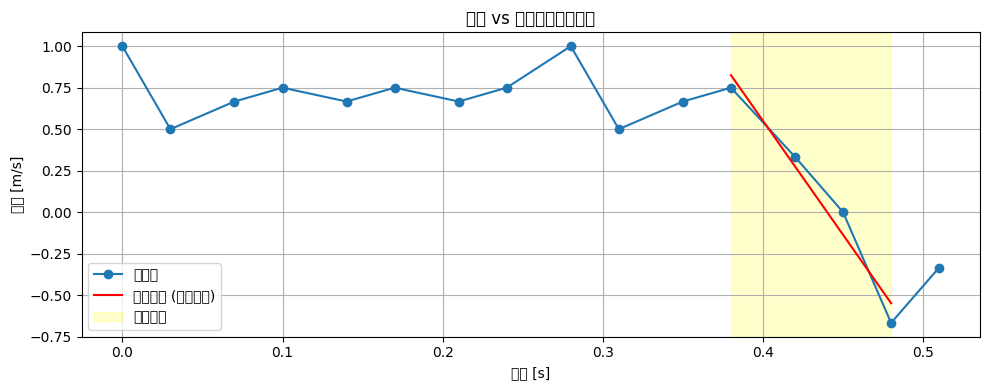

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# --- Step 0: Sample Data ---
class MovingPoint:
    def __init__(self, distance, time):
        self.distance = distance  # [m] カップからの距離
        self.time = time          # [s] 絶対時間

# ボールがカップに向かって減速、後に跳ね返るようなデータ
data_points = [
    MovingPoint(0.65, 0.00),
    MovingPoint(0.62, 0.03),
    MovingPoint(0.60, 0.07),
    MovingPoint(0.58, 0.10),
    MovingPoint(0.55, 0.14),
    MovingPoint(0.53, 0.17),
    MovingPoint(0.50, 0.21),
    MovingPoint(0.48, 0.24),
    MovingPoint(0.45, 0.28),
    MovingPoint(0.42, 0.31),
    MovingPoint(0.40, 0.35),
    MovingPoint(0.38, 0.38),
    MovingPoint(0.35, 0.42),
    MovingPoint(0.34, 0.45),
    MovingPoint(0.34, 0.48),
    MovingPoint(0.36, 0.51),  # 逆転（跳ね返り）
    MovingPoint(0.37, 0.54),
]

# --- Step 1: 速度計算 ---
distances = np.array([p.distance for p in data_points])
times = np.array([p.time for p in data_points])
speeds = (distances[:-1] - distances[1:]) / (times[1:] - times[:-1])
mid_times = times[:-1]

# --- Step 2: 減速が安定している区間の抽出 ---
tolerance = 0.01
segment_start = 0
best_segment = (0, 0)

for i in range(1, len(speeds)):
    if speeds[i] > speeds[i - 1] + tolerance:
        segment_end = i
        if segment_end - segment_start >= 3:
            if best_segment[1] - best_segment[0] < segment_end - segment_start:
                best_segment = (segment_start, segment_end)
        segment_start = i

# 最後の区間も評価
if (len(speeds) - segment_start) > (best_segment[1] - best_segment[0]):
    best_segment = (segment_start, len(speeds))

start, end = best_segment
segment_speeds = speeds[start:end]
segment_times = mid_times[start:end]

if len(segment_speeds) < 3:
    raise ValueError("十分な減速区間が見つかりませんでした。")

# --- Step 3: 回帰分析（速度 vs 時間） ---
X = segment_times.reshape(-1, 1)
y = segment_speeds
model = LinearRegression()
model.fit(X, y)
slope = model.coef_[0]
intercept = model.intercept_

# --- Step 4: 摩擦係数の推定 ---
acceleration = slope  # 負の値
std_acc = np.std(np.diff(segment_speeds) / np.diff(segment_times))
g = 9.80665  # m/s²
mu = -acceleration / g

# --- Step 5: ログ出力 ---
print("✅ 減速が安定していると判断された区間:")
for i in range(start, end):
    print(f"  時刻: {mid_times[i]:.2f}s, 速度: {speeds[i]:.3f} m/s")

print(f"\n推定加速度: a = {acceleration:.4f} m/s²")
print(f"加速度の標準偏差: {std_acc:.4f} m/s²")
print(f"推定摩擦係数: μ = {mu:.4f}")

# --- Step 6: グラフ描画 ---
plt.figure(figsize=(10, 4))
plt.plot(mid_times, speeds, label="全速度", marker='o')
plt.plot(segment_times, model.predict(X), label="回帰直線 (減速区間)", color='red')
plt.axvspan(mid_times[start], mid_times[end-1], color='yellow', alpha=0.2, label="使用区間")
plt.xlabel("時間 [s]")
plt.ylabel("速度 [m/s]")
plt.title("速度 vs 時間（減速区間）")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
